#Analysis & Visualization

In [1]:
import os

# Colab-only: mount Google Drive if available.
try:
    from google.colab import drive  # type: ignore

    drive.mount('/content/drive')
except Exception:
    # Not running in Google Colab (or Drive not available).
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "/content/drive/MyDrive/EEG_Proj/كلمات"
TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]
TARGET_SET = set(TARGET_WORDS)

EEG_CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]
FS = 128

print("DATA_ROOT exists?", os.path.exists(DATA_ROOT))
print("Folders (first 30):", [os.path.basename(p) for p in sorted(glob.glob(os.path.join(DATA_ROOT, "*"))) if os.path.isdir(p)][:30])


DATA_ROOT exists? True
Folders (first 30): ['اختر', 'اسفل', 'اعلى', 'انذار', 'ايقاف تشغيل', 'تشغيل', 'جوع', 'حذف', 'حمام', 'دواء', 'عطش', 'لا', 'مسافة', 'نعم', 'يسار', 'يمين']


#CSV reader (subject from title column) + EEG column mapping

In [3]:
def normalize_col(c: str) -> str:
    c = str(c).replace("\ufeff", "").strip()
    c = c.replace("EEG.", "").replace("EEG ", "").replace("EEG_", "")
    c = c.replace("RAW.", "").replace("RAW ", "")
    c = c.replace(" ", "")
    return c

def parse_title_value(title_val: str):
    """
    title_val مثال: "title:حازم جوع" أو "حازم جوع"
    يرجع (subject, phrase)
    """
    if title_val is None or (isinstance(title_val, float) and pd.isna(title_val)):
        return None, None
    s = str(title_val).strip()
    s = re.sub(r"^title\s*:\s*", "", s).strip()
    parts = s.split()
    if len(parts) < 2:
        return parts[0].strip() if parts else None, None
    return parts[0].strip(), " ".join(parts[1:]).strip()

def parse_metadata_title(first_line: str):
    """
    يلقط من سطر مثل:
    title:حازم جوع, start:..., ...
    """
    if not isinstance(first_line, str):
        return None, None
    m = re.search(r"title\s*:\s*([^,]+)", first_line)
    if not m:
        return None, None
    return parse_title_value(m.group(1).strip())

def read_trial_csv(csv_path: str):
    # اقرأ أول سطر (ميتاداتا) للاحتياط
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        first_line = f.readline().strip()

    # اقرأ الجدول (تخطّي سطر الميتاداتا)
    df = pd.read_csv(csv_path, skiprows=1)
    df.columns = [normalize_col(c) for c in df.columns]

    subject_name, phrase = None, None

    # 1) حاول من عمود title (مرن: title/Title/أي عمود يبدأ بـ title)
    title_candidates = [c for c in df.columns if str(c).lower().startswith("title")]
    if len(title_candidates) > 0:
        title_col = title_candidates[0]
        series = df[title_col].dropna()
        if len(series) > 0:
            subject_name, phrase = parse_title_value(series.iloc[0])

    # 2) fallback: حاول من سطر الميتاداتا الأول
    if subject_name is None:
        subject_name, phrase = parse_metadata_title(first_line)

    return df, subject_name, phrase

def find_eeg_columns(df):
    colset = set(df.columns)
    mapping = {}
    for ch in EEG_CHANNELS:
        if ch in colset:
            mapping[ch] = ch
            continue
        candidates = [c for c in df.columns if str(c).startswith(ch)]
        if len(candidates) == 1:
            mapping[ch] = candidates[0]
        elif len(candidates) > 1:
            mapping[ch] = sorted(candidates, key=len)[0]
        else:
            mapping[ch] = None
    return mapping



#Scan only the 5 classes and build a clean metadata table

In [4]:

# collect csvs from target folders
word_folders = sorted([p for p in glob.glob(os.path.join(DATA_ROOT, "*")) if os.path.isdir(p)])
target_folders = [p for p in word_folders if os.path.basename(p) in TARGET_SET]

print("Target folders found:", [os.path.basename(p) for p in target_folders])

all_csvs = []
for folder in target_folders:
    all_csvs.extend(sorted(glob.glob(os.path.join(folder, "*.csv"))))

print("Total CSV trials (5 classes):", len(all_csvs))

records = []
for path in all_csvs:
    word = os.path.basename(os.path.dirname(path))
    try:
        df, subject, phrase = read_trial_csv(path)
        mapping = find_eeg_columns(df)
        found = sum(1 for _,v in mapping.items() if v is not None)
        records.append({
            "path": path,
            "word": word,
            "subject_name": subject,
            "title_phrase": phrase,
            "n_samples": len(df),
            "eeg_cols_found": found,
            "missing": ",".join([ch for ch,v in mapping.items() if v is None]),
            "error": None
        })
    except Exception as e:
        records.append({
            "path": path,
            "word": word,
            "subject_name": None,
            "title_phrase": None,
            "n_samples": None,
            "eeg_cols_found": 0,
            "missing": ",".join(EEG_CHANNELS),
            "error": str(e)
        })

meta_df = pd.DataFrame(records)
ok_df = meta_df[(meta_df["error"].isna()) &
                (meta_df["eeg_cols_found"] == len(EEG_CHANNELS)) &
                (meta_df["subject_name"].notna())].copy()

print("OK trials:", len(ok_df), "/", len(meta_df))
print("Unique subjects:", ok_df["subject_name"].nunique())
ok_df.head(5)


Target folders found: ['انذار', 'جوع', 'حمام', 'دواء', 'عطش']
Total CSV trials (5 classes): 113
OK trials: 113 / 113
Unique subjects: 22


,path,word,subject_name,title_phrase,n_samples,eeg_cols_found,missing,error
0,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,aya,انذار,1454,14,,None
1,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,شويكي,انذار,1384,14,,None
2,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,صنجي,انذار,1382,14,,None
3,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,عمار,انذار,1379,14,,None
4,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,فارس,انذار,1361,14,,None


#Visualization

##Class distribution + Subject distribution

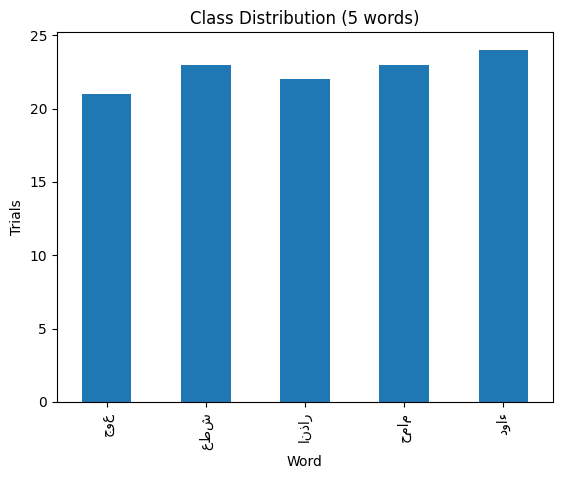

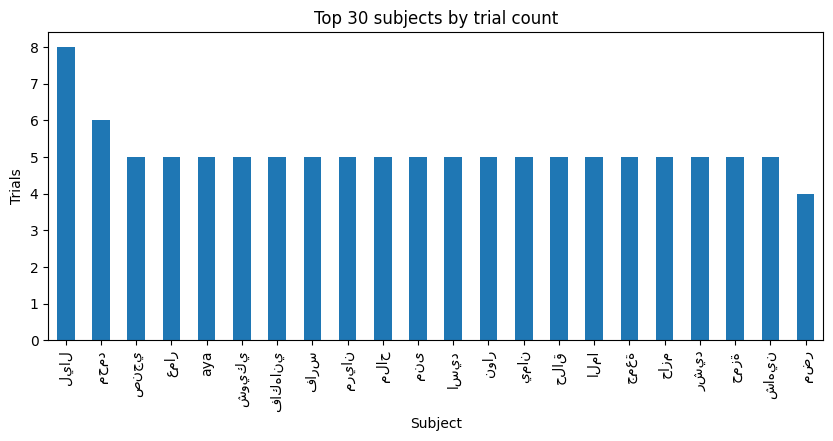

Trials per subject summary:
count    22.000000
mean      5.136364
std       0.710161
min       4.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       8.000000
Name: count, dtype: float64


In [ ]:
# Class distribution (ordered)
plt.figure()
ok_df["word"].value_counts().reindex(TARGET_WORDS).plot(kind="bar")
plt.title("Class Distribution (5 words)")
plt.xlabel("Word")
plt.ylabel("Trials")
plt.show()

# Subject distribution
sub_counts = ok_df["subject_name"].value_counts()
plt.figure(figsize=(10,4))
sub_counts.head(30).plot(kind="bar")
plt.title("Top 30 subjects by trial count")
plt.xlabel("Subject")
plt.ylabel("Trials")
plt.show()

print("Trials per subject summary:")
print(sub_counts.describe())


##Trial length distribution (seconds + samples)

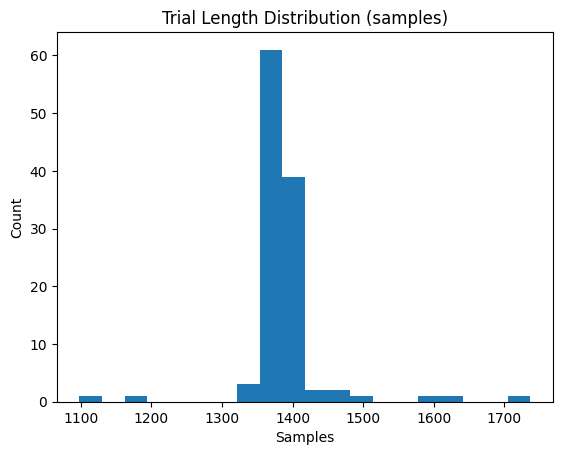

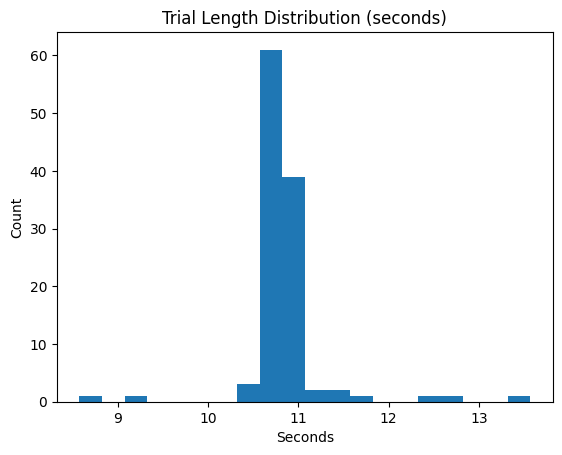

Length stats (samples):
count     113.000000
mean     1389.743363
std        58.079038
min      1098.000000
25%      1378.000000
50%      1384.000000
75%      1393.000000
max      1737.000000
dtype: float64


In [ ]:
lengths = ok_df["n_samples"].to_numpy()
plt.figure()
plt.hist(lengths, bins=20)
plt.title("Trial Length Distribution (samples)")
plt.xlabel("Samples")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(lengths/FS, bins=20)
plt.title("Trial Length Distribution (seconds)")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

print("Length stats (samples):")
print(pd.Series(lengths).describe())


##Pick one trial and plot raw signals (4 channels) + check missing/NaN

Example: par.3 عطش_EPOCX_206412_2023.12.24T11.06.51+03.00.md.csv
word: عطش | subject: الما | phrase: عطش
EEG shape: (14, 1385)
NaN count: 0


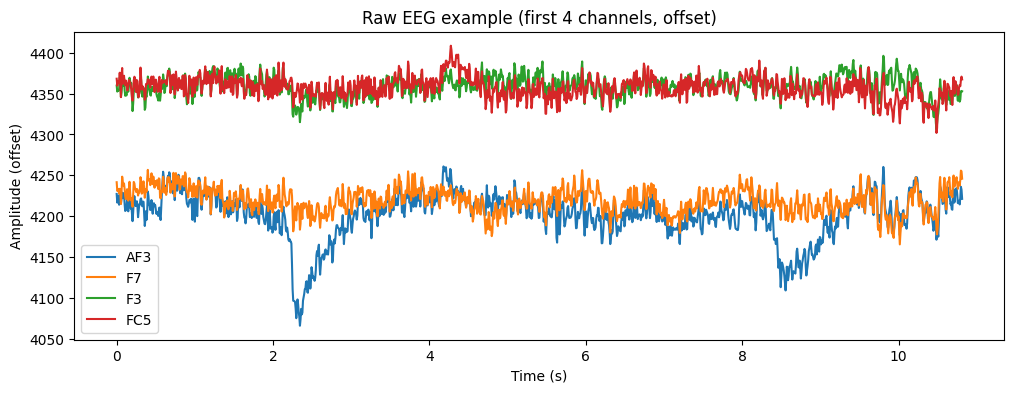

In [ ]:
# pick a random OK trial
row = ok_df.sample(1, random_state=0).iloc[0]
df, subject, phrase = read_trial_csv(row["path"])
mapping = find_eeg_columns(df)

# build eeg matrix (raw)
eeg = np.stack([df[mapping[ch]].to_numpy(dtype=float) for ch in EEG_CHANNELS], axis=0)

print("Example:", os.path.basename(row["path"]))
print("word:", row["word"], "| subject:", subject, "| phrase:", phrase)
print("EEG shape:", eeg.shape)
print("NaN count:", np.isnan(eeg).sum())

# plot first 4 channels with offsets
t = np.arange(eeg.shape[1]) / FS
plt.figure(figsize=(12,4))
for i, ch in enumerate(EEG_CHANNELS[:4]):
    plt.plot(t, eeg[i] + i*np.nanstd(eeg[i])*3, label=ch)
plt.title("Raw EEG example (first 4 channels, offset)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (offset)")
plt.legend()
plt.show()


In [ ]:
# ====== INSPECT ANY ONE FILE (DEBUG CELL - FIXED) ======

import pandas as pd
import numpy as np
import re

# اختر ملف (عشوائي من ok_df)
row = ok_df.sample(1, random_state=42).iloc[0]
file_path = row["path"]

print("="*80)
print("FILE:", file_path)
print("="*80)

# 1️⃣ اقرأ أول سطر (metadata line)
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    first_line = f.readline().strip()

print("\n--- FIRST LINE (Metadata) ---")
print(first_line)

# 2️⃣ اقرأ الجدول بدون تنظيف
df_raw = pd.read_csv(file_path, skiprows=1)

print("\n--- RAW COLUMNS ---")
print(df_raw.columns.tolist())

print("\n--- RAW SHAPE ---")
print(df_raw.shape)

print("\n--- RAW HEAD (first 5 rows) ---")
display(df_raw.head())

# 3️⃣ تنظيف أسماء الأعمدة
def normalize_col(c: str) -> str:
    c = str(c).replace("\ufeff", "").strip()
    c = c.replace("EEG.", "").replace("EEG ", "").replace("EEG_", "")
    c = c.replace("RAW.", "").replace("RAW ", "")
    c = c.replace(" ", "")
    return c

df = df_raw.copy()
df.columns = [normalize_col(c) for c in df.columns]

print("\n--- CLEANED COLUMNS ---")
print(df.columns.tolist())

print("\n--- CLEANED SHAPE ---")
print(df.shape)

# 4️⃣ استخراج subject و phrase (robust: title column OR metadata line)
def parse_title_value(title_val: str):
    """
    title_val مثال: 'title:حازم جوع' أو 'حازم جوع'
    يرجع (subject, phrase)
    """
    if title_val is None or (isinstance(title_val, float) and pd.isna(title_val)):
        return None, None
    s = str(title_val).strip()
    s = re.sub(r"^title\s*:\s*", "", s).strip()
    parts = s.split()
    if len(parts) < 2:
        return parts[0].strip() if parts else None, None
    return parts[0].strip(), " ".join(parts[1:]).strip()

def parse_metadata_title(first_line: str):
    """
    يلقط من سطر مثل:
    title:حازم جوع, start:..., ...
    """
    if not isinstance(first_line, str):
        return None, None
    m = re.search(r"title\s*:\s*([^,]+)", first_line)
    if not m:
        return None, None
    return parse_title_value(m.group(1).strip())

subject_name, phrase = None, None

# 4.1 حاول من عمود title إن وجد (مرن: أي عمود يبدأ بـ title)
title_candidates = [c for c in df.columns if str(c).lower().startswith("title")]
if len(title_candidates) > 0:
    title_col = title_candidates[0]
    series = df[title_col].dropna()
    if len(series) > 0:
        subject_name, phrase = parse_title_value(series.iloc[0])

# 4.2 fallback: من سطر الميتاداتا الأول
if subject_name is None:
    subject_name, phrase = parse_metadata_title(first_line)

print("\n--- Extracted Subject & Phrase ---")
print("Subject:", subject_name)
print("Phrase :", phrase)

# 5️⃣ عرض أول 5 صفوف من قنوات EEG فقط
EEG_CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]
available_eeg = [ch for ch in EEG_CHANNELS if ch in df.columns]

print("\n--- EEG Channels Found ---")
print(available_eeg)
print("EEG channels count:", len(available_eeg))

print("\n--- EEG HEAD (first 5 rows) ---")
display(df[available_eeg].head())

# 6️⃣ تحقق من NaNs
print("\n--- NaN Count per EEG Channel ---")
print(df[available_eeg].isna().sum())

print("\nTotal NaNs:", int(df[available_eeg].isna().sum().sum()))


FILE: /content/drive/MyDrive/EEG_Proj/كلمات/دواء/par.21 دواء_EPOCX_206412_2023.12.24T12.54.00+03.00.md.csv

--- FIRST LINE (Metadata) ---
title:منى دواء, start timestamp:1703411640.936505, stop timestamp:1703411651.797504, headset type:EPOCX, headset serial:E50206EF, headset firmware:720, channels:67, sampling rate:eeg_128;mot_32, samples:1392      , version:2.2,

--- RAW COLUMNS ---
['Timestamp', 'OriginalTimestamp', 'EEG.Counter', 'EEG.Interpolated', 'EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4', 'EEG.RawCq', 'EEG.Battery', 'EEG.BatteryPercent', 'MarkerIndex', 'MarkerType', 'MarkerValueInt', 'EEG.MarkerHardware', 'CQ.AF3', 'CQ.F7', 'CQ.F3', 'CQ.FC5', 'CQ.T7', 'CQ.P7', 'CQ.O1', 'CQ.O2', 'CQ.P8', 'CQ.T8', 'CQ.FC6', 'CQ.F4', 'CQ.F8', 'CQ.AF4', 'CQ.Overall', 'EQ.SampleRateQuality', 'EQ.OVERALL', 'EQ.AF3', 'EQ.F7', 'EQ.F3', 'EQ.FC5', 'EQ.T7', 'EQ.P7', 'EQ.O1', 'EQ.O2', 'EQ.P8', 'EQ.T8', 'EQ.FC

,Timestamp,OriginalTimestamp,EEG.Counter,EEG.Interpolated,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,...,MOT.Q0,MOT.Q1,MOT.Q2,MOT.Q3,MOT.AccX,MOT.AccY,MOT.AccZ,MOT.MagX,MOT.MagY,MOT.MagZ
0,1.703412e+09,1.703412e+09,40.0,0.0,4189.230957,4172.948730,4267.179688,4258.333496,4172.179688,4150.512695,...,0.742920,0.05072,-0.663391,0.073547,0.999634,-0.02344,0.106458,-17.791880,-36.659866,65.678864
1,1.703412e+09,1.703412e+09,41.0,0.0,4197.307617,4187.051270,4273.461426,4272.051270,4181.922852,4153.717773,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.703412e+09,1.703412e+09,42.0,0.0,4170.128418,4164.871582,4271.666504,4259.358887,4174.102539,4155.384766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.703412e+09,1.703412e+09,43.0,0.0,4176.922852,4161.794922,4256.025879,4244.871582,4174.871582,4154.871582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.703412e+09,1.703412e+09,44.0,0.0,4208.589844,4182.436035,4249.230957,4255.256348,4184.487305,4147.436035,...,0.742799,0.05072,-0.663513,0.073669,0.986937,-0.01172,0.102552,-17.762691,-36.710545,65.644310



--- CLEANED COLUMNS ---
['Timestamp', 'OriginalTimestamp', 'Counter', 'Interpolated', 'AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerIndex', 'MarkerType', 'MarkerValueInt', 'MarkerHardware', 'CQ.AF3', 'CQ.F7', 'CQ.F3', 'CQ.FC5', 'CQ.T7', 'CQ.P7', 'CQ.O1', 'CQ.O2', 'CQ.P8', 'CQ.T8', 'CQ.FC6', 'CQ.F4', 'CQ.F8', 'CQ.AF4', 'CQ.Overall', 'EQ.SampleRateQuality', 'EQ.OVERALL', 'EQ.AF3', 'EQ.F7', 'EQ.F3', 'EQ.FC5', 'EQ.T7', 'EQ.P7', 'EQ.O1', 'EQ.O2', 'EQ.P8', 'EQ.T8', 'EQ.FC6', 'EQ.F4', 'EQ.F8', 'EQ.AF4', 'MOT.CounterMems', 'MOT.InterpolatedMems', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ']

--- CLEANED SHAPE ---
(1392, 68)

--- Extracted Subject & Phrase ---
Subject: منى
Phrase : دواء

--- EEG Channels Found ---
['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
EEG channels count: 14

--- EEG HEAD (fir

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4189.230957,4172.948730,4267.179688,4258.333496,4172.179688,4150.512695,4208.461426,4181.922852,4181.666504,4155.641113,4558.846191,4435.769043,4335.128418,4482.179688
1,4197.307617,4187.051270,4273.461426,4272.051270,4181.922852,4153.717773,4217.051270,4195.256348,4189.230957,4181.538574,4572.948730,4447.563965,4362.051270,4490.769043
2,4170.128418,4164.871582,4271.666504,4259.358887,4174.102539,4155.384766,4216.794922,4191.538574,4183.974121,4186.666504,4567.820313,4436.153809,4363.077148,4484.743652
3,4176.922852,4161.794922,4256.025879,4244.871582,4174.871582,4154.871582,4212.820313,4184.102539,4182.692383,4165.128418,4566.153809,4427.179688,4356.666504,4482.948730
4,4208.589844,4182.436035,4249.230957,4255.256348,4184.487305,4147.436035,4216.153809,4186.410156,4187.436035,4166.538574,4572.692383,4436.794922,4366.153809,4490.769043



--- NaN Count per EEG Channel ---
AF3    0
F7     0
F3     0
FC5    0
T7     0
P7     0
O1     0
O2     0
P8     0
T8     0
FC6    0
F4     0
F8     0
AF4    0
dtype: int64

Total NaNs: 0


#Line noise + spectrum analysis

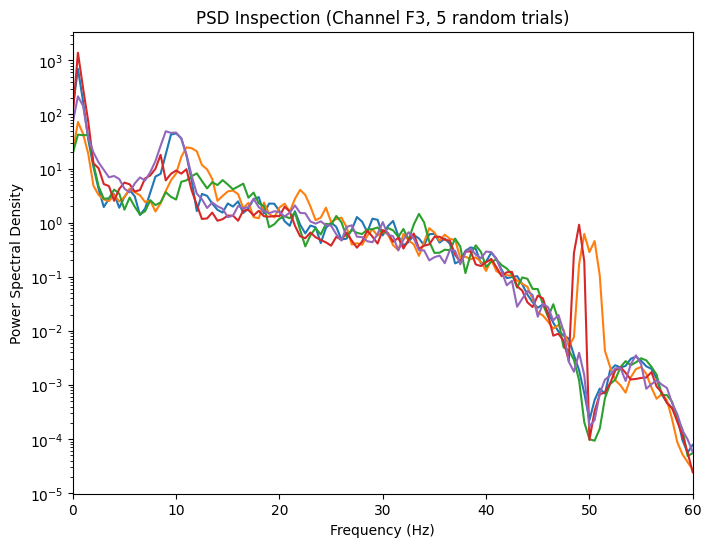

In [ ]:
# ====== QUALITY CHECK 1: PSD Inspection ======

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# اختر 5 ترايلز عشوائية للفحص
sample_rows = ok_df.sample(5, random_state=1)

plt.figure(figsize=(8,6))

for _, row in sample_rows.iterrows():
    df, subject, phrase = read_trial_csv(row["path"])
    mapping = find_eeg_columns(df)

    # خذ قناة واحدة ثابتة للفحص (مثلاً F3)
    ch = "F3"
    signal_data = df[mapping[ch]].to_numpy(dtype=float)

    f, pxx = welch(signal_data, fs=FS, nperseg=256)

    plt.semilogy(f, pxx)

plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("PSD Inspection (Channel F3, 5 random trials)")
plt.show()


#preprocessing pipeline (High-pass/Low-pass + Notch + CAR)

##Preprocessing Functions (Bandpass 1–40 + Notch 50 + CAR)

In [5]:
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch, detrend

FS = 128
EEG_CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a

def apply_preprocessing(eeg_2d, fs=128, low=1.0, high=40.0, notch_hz=50.0, notch_q=30.0, use_car=True):
    """
    eeg_2d: shape (channels, samples)
    returns: processed eeg_2d (channels, samples)
    Pipeline:
      1) detrend (linear)
      2) bandpass 1-40 Hz
      3) notch 50 Hz
      4) CAR
    """
    x = eeg_2d.astype(np.float64)

    # 1) detrend (helps drift)
    x = detrend(x, axis=1, type="linear")

    # 2) bandpass 1-40
    b, a = butter_bandpass(low, high, fs, order=4)
    x = filtfilt(b, a, x, axis=1)

    # 3) notch at 50 (if feasible w.r.t Nyquist)
    w0 = notch_hz / (fs / 2.0)
    if w0 < 1.0:
        bn, an = iirnotch(w0, Q=notch_q)
        x = filtfilt(bn, an, x, axis=1)

    # 4) CAR
    if use_car:
        x = x - np.mean(x, axis=0, keepdims=True)

    return x


##Apply to One Trial + Plot Before/After (Time Domain)

File: par.3 عطش_EPOCX_206412_2023.12.24T11.06.51+03.00.md.csv
word: عطش | subject: الما | phrase: عطش
raw shape: (14, 1385) proc shape: (14, 1385)


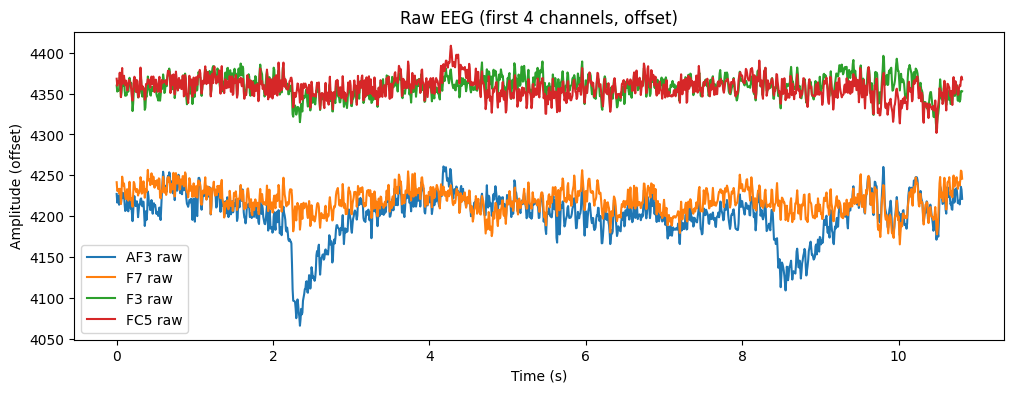

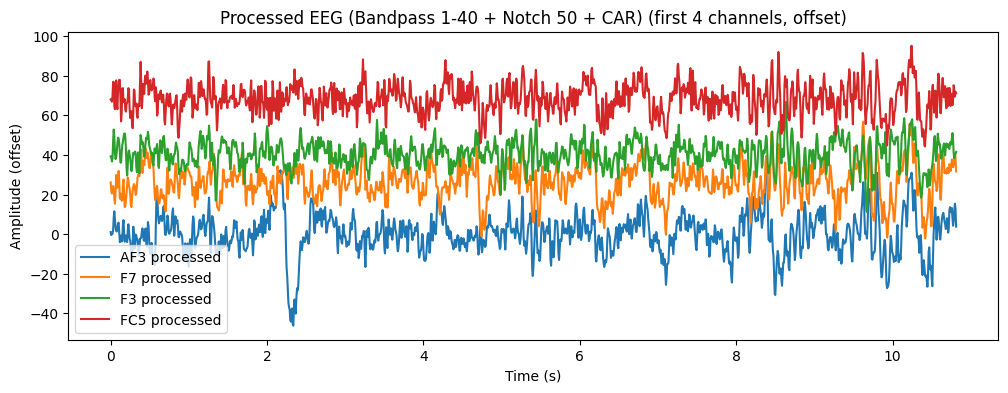

In [6]:
import matplotlib.pyplot as plt

# اختر trial واحد من ok_df
row = ok_df.sample(1, random_state=0).iloc[0]
df, subject, phrase = read_trial_csv(row["path"])
mapping = find_eeg_columns(df)

# raw eeg (14, T)
raw = np.stack([df[mapping[ch]].to_numpy(dtype=float) for ch in EEG_CHANNELS], axis=0)

# processed
proc = apply_preprocessing(raw, fs=FS, low=1.0, high=40.0, notch_hz=50.0, use_car=True)

print("File:", row["path"].split("/")[-1])
print("word:", row["word"], "| subject:", subject, "| phrase:", phrase)
print("raw shape:", raw.shape, "proc shape:", proc.shape)

# Plot first 4 channels raw vs processed (offset)
t = np.arange(raw.shape[1]) / FS
ch_to_plot = EEG_CHANNELS[:4]

plt.figure(figsize=(12,4))
for i, ch in enumerate(ch_to_plot):
    plt.plot(t, raw[i] + i*np.nanstd(raw[i])*3, label=f"{ch} raw")
plt.title("Raw EEG (first 4 channels, offset)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (offset)")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
for i, ch in enumerate(ch_to_plot):
    plt.plot(t, proc[i] + i*np.nanstd(proc[i])*3, label=f"{ch} processed")
plt.title("Processed EEG (Bandpass 1-40 + Notch 50 + CAR) (first 4 channels, offset)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (offset)")
plt.legend()
plt.show()


الإشارة أصبحت centered حول الصفر → ✔ CAR يعمل

الانحرافات البطيئة اختفت → ✔ high-pass فعال

لا يوجد تشويه غريب

لا يوجد ringing واضح من الفلتر

##PSD Before/After

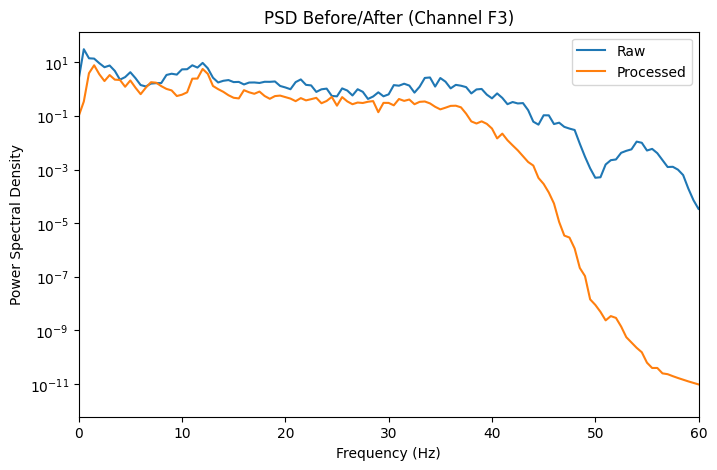

In [ ]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# اختر قناة للفحص (F3)
ch_name = "F3"
ch_idx = EEG_CHANNELS.index(ch_name)

f_raw, p_raw = welch(raw[ch_idx], fs=FS, nperseg=256)
f_pro, p_pro = welch(proc[ch_idx], fs=FS, nperseg=256)

plt.figure(figsize=(8,5))
plt.semilogy(f_raw, p_raw, label="Raw")
plt.semilogy(f_pro, p_pro, label="Processed")
plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(f"PSD Before/After (Channel {ch_name})")
plt.legend()
plt.show()


القمة عند 50Hz اختفت تقريبًا بالكامل

الطاقة فوق 40Hz انخفضت بشدة

#نعمم البايبلاين +  z-score

In [7]:
import numpy as np
import pandas as pd
import os
from scipy.signal import butter, filtfilt, iirnotch, detrend

FS = 128
EEG_CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]
TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]
word_to_id = {w:i for i,w in enumerate(TARGET_WORDS)}

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype="band")
    return b, a

def apply_preprocessing(eeg_2d, fs=128, low=1.0, high=40.0, notch_hz=50.0, notch_q=30.0, use_car=True, use_zscore=True):
    """
    eeg_2d: (channels, samples)
    Pipeline:
      1) detrend
      2) bandpass 1-40
      3) notch 50
      4) CAR
      5) z-score per channel (within trial)
    """
    x = eeg_2d.astype(np.float64)

    # 1) detrend
    x = detrend(x, axis=1, type="linear")

    # 2) bandpass
    b, a = butter_bandpass(low, high, fs, order=4)
    x = filtfilt(b, a, x, axis=1)

    # 3) notch
    w0 = notch_hz / (fs / 2.0)
    if w0 < 1.0:
        bn, an = iirnotch(w0, Q=notch_q)
        x = filtfilt(bn, an, x, axis=1)

    # 4) CAR
    if use_car:
        x = x - np.mean(x, axis=0, keepdims=True)

    # 5) z-score per channel
    if use_zscore:
        mu = np.mean(x, axis=1, keepdims=True)
        sd = np.std(x, axis=1, keepdims=True) + 1e-8
        x = (x - mu) / sd

    return x

# ===== Build dataset (no windowing yet) =====
X_list, y_list, groups_list = [], [], []
rows = []

for _, r in ok_df.iterrows():
    path = r["path"]
    word = r["word"]
    subject = r["subject_name"]

    df, subject2, phrase = read_trial_csv(path)
    mapping = find_eeg_columns(df)

    raw = np.stack([df[mapping[ch]].to_numpy(dtype=float) for ch in EEG_CHANNELS], axis=0)  # (14, T)
    proc = apply_preprocessing(raw, fs=FS, low=1.0, high=40.0, notch_hz=50.0, use_car=True, use_zscore=True)

    X_list.append(proc.astype(np.float32))
    y_list.append(word_to_id[word])
    groups_list.append(subject)

    rows.append({
        "path": path,
        "word": word,
        "y": word_to_id[word],
        "subject_name": subject,
        "title_phrase": r["title_phrase"],
        "n_samples": int(r["n_samples"])
    })

X = np.empty(len(X_list), dtype=object)
X[:] = X_list

y = np.array(y_list, dtype=np.int64)
groups = np.array(groups_list)


meta_out = pd.DataFrame(rows)

print("Trials:", len(X))
print("y shape:", y.shape, "groups shape:", groups.shape)
print("Unique subjects:", len(np.unique(groups)))
print("Example trial shape:", X[0].shape)
meta_out.head()

print("Trials:", len(X))
print("Example trial type:", type(X[0]))
print("Example trial shape:", X[0].shape)
print("Min/Max lengths:", min(x.shape[1] for x in X), max(x.shape[1] for x in X))



Trials: 113
y shape: (113,) groups shape: (113,)
Unique subjects: 22
Example trial shape: (14, 1454)
Trials: 113
Example trial type: <class 'numpy.ndarray'>
Example trial shape: (14, 1454)
Min/Max lengths: 1098 1737


In [ ]:
OUT_DIR = "/content/drive/MyDrive/EEG_Proj/processed_5words_fulltrials"
os.makedirs(OUT_DIR, exist_ok=True)

npz_path = os.path.join(OUT_DIR, "areeg_5words_preprocessed_fulltrials.npz")
csv_path = os.path.join(OUT_DIR, "areeg_5words_metadata_fulltrials.csv")

# نحفظ X كـ object array داخل npz
np.savez_compressed(
    npz_path,
    X=X,
    y=y,
    groups=groups,
    fs=FS,
    channels=np.array(EEG_CHANNELS),
    words=np.array(TARGET_WORDS),
)

meta_out.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:")
print(npz_path)
print(csv_path)


Saved:
/content/drive/MyDrive/EEG_Proj/processed_5words_fulltrials/areeg_5words_preprocessed_fulltrials.npz
/content/drive/MyDrive/EEG_Proj/processed_5words_fulltrials/areeg_5words_metadata_fulltrials.csv


#Trial-level Quality Filtering

In [8]:
import numpy as np
import pandas as pd
from scipy.signal import welch

def bandpower_welch(x, fs, fmin, fmax):
    f, p = welch(x, fs=fs, nperseg=min(256, len(x)))
    m = (f >= fmin) & (f < fmax)
    if not np.any(m):
        return 0.0
    return float(np.trapz(p[m], f[m]))

rows = []
for i in range(len(X)):
    trial = X[i]  # (14, T) after preprocessing + zscore
    T = trial.shape[1]

    # RMS + PTP per channel
    rms_ch = np.sqrt(np.mean(trial**2, axis=1))
    ptp_ch = np.ptp(trial, axis=1)  # max-min

    # flatline-ish: fraction of diffs that are ~0
    # (بعد zscore المفروض ما تكون كثيرة إلا لو فيه مشاكل)
    diffs = np.abs(np.diff(trial, axis=1))
    flat_frac = float(np.mean(diffs < 1e-6))

    # spectral ratios على قناة وسطية (F3) كفحص ثابت
    # (ممكن لاحقاً نعمل متوسط عبر القنوات، لكن نبدأ بسيط)
    ch_idx = 2  # F3 index in EEG_CHANNELS list (AF3=0,F7=1,F3=2)
    xch = trial[ch_idx]

    p_1_30  = bandpower_welch(xch, FS, 1, 30)
    p_30_40 = bandpower_welch(xch, FS, 30, 40)
    p_49_51 = bandpower_welch(xch, FS, 49, 51)  # قرب 50Hz

    hf_ratio = (p_30_40 / (p_1_30 + 1e-12))
    line50_ratio = (p_49_51 / (p_1_30 + 1e-12))

    rows.append({
        "i": i,
        "word": meta_out.loc[i, "word"],
        "subject": meta_out.loc[i, "subject_name"],
        "T": T,
        "rms_mean": float(np.mean(rms_ch)),
        "rms_max": float(np.max(rms_ch)),
        "ptp_mean": float(np.mean(ptp_ch)),
        "ptp_max": float(np.max(ptp_ch)),
        "flat_frac": flat_frac,
        "hf_ratio": float(hf_ratio),
        "line50_ratio": float(line50_ratio),
    })

quality_df = pd.DataFrame(rows)

print("quality_df shape:", quality_df.shape)
quality_df.head()


/tmp/ipykernel_4029/3430359234.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(p[m], f[m]))


quality_df shape: (113, 11)


,i,word,subject,T,rms_mean,rms_max,ptp_mean,ptp_max,flat_frac,hf_ratio,line50_ratio
0,0,انذار,aya,1454,1.0,1.0,8.068872,11.826637,0.0,0.040060,1.037370e-09
1,1,انذار,شويكي,1384,1.0,1.0,6.752369,9.924711,0.0,0.016016,4.431038e-09
2,2,انذار,صنجي,1382,1.0,1.0,7.096665,10.111254,0.0,0.012462,1.440612e-09
3,3,انذار,عمار,1379,1.0,1.0,6.910491,10.007726,0.0,0.024648,4.645306e-09
4,4,انذار,فارس,1361,1.0,1.0,9.399430,11.237808,0.0,0.031845,2.410302e-07


#Visualize & Find Outliers

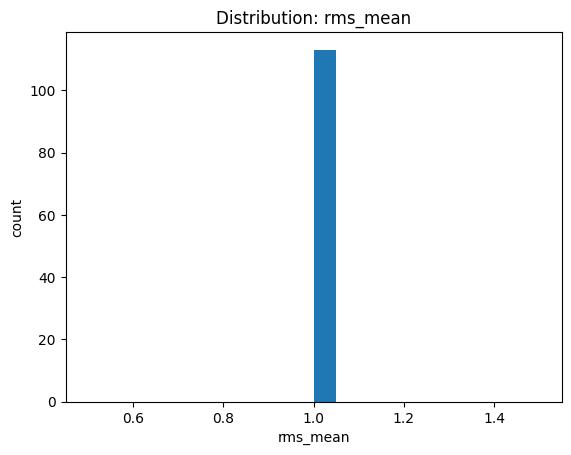

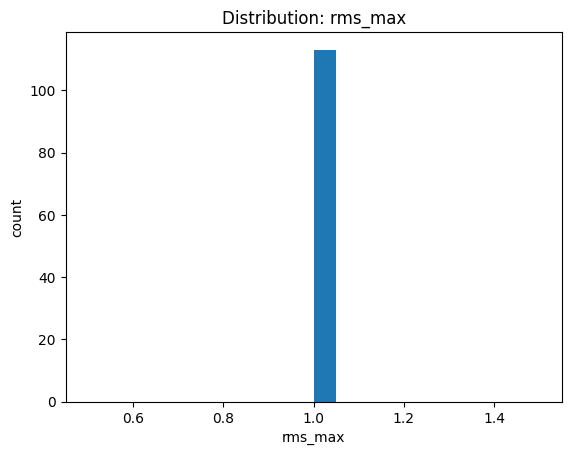

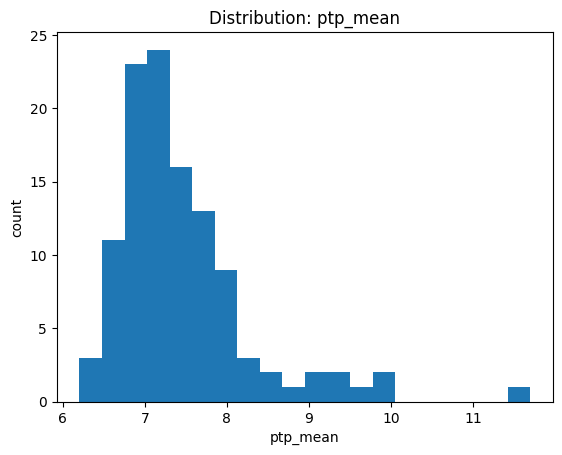

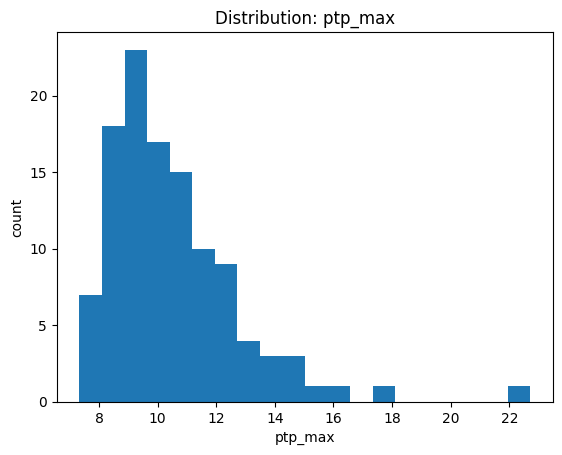

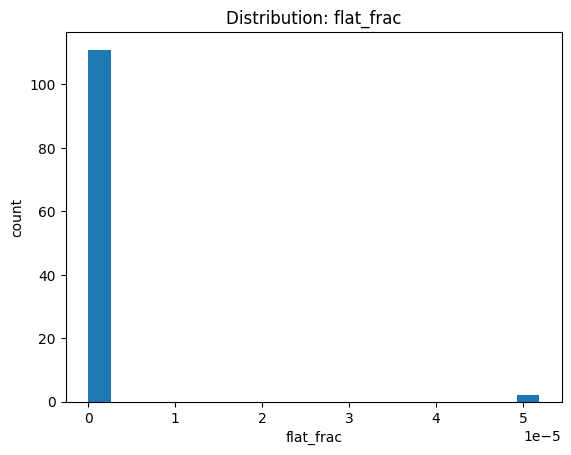

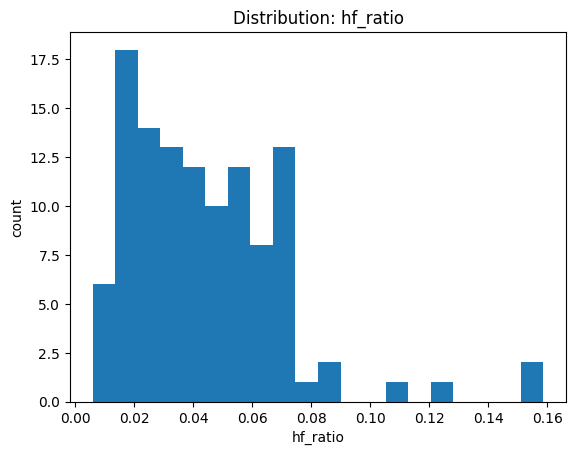

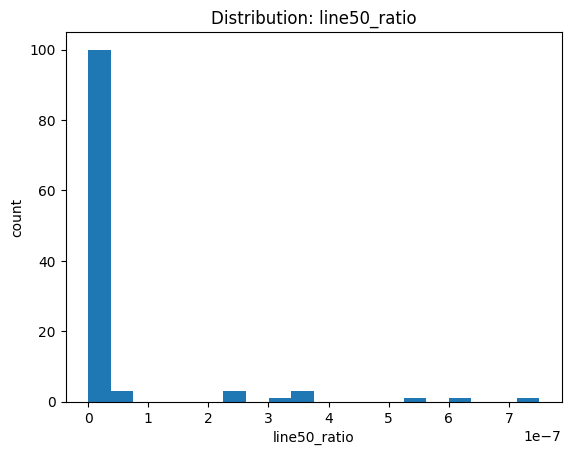


Top 10 by ptp_max (spikiest trials):


,i,word,subject,T,rms_mean,rms_max,ptp_mean,ptp_max,flat_frac,hf_ratio,line50_ratio
8,8,انذار,مريان,1377,1.0,1.0,10.012957,22.717190,0.000000,0.158761,2.892329e-09
37,37,جوع,جمعة,1385,1.0,1.0,9.179972,18.039873,0.000000,0.040070,2.501776e-09
79,79,دواء,ملاح,1436,1.0,1.0,11.697579,15.885326,0.000000,0.008761,2.894020e-10
32,32,جوع,منى,1376,1.0,1.0,7.939747,15.227041,0.000000,0.058202,2.298252e-09
43,43,حمام,اسيد,1378,1.0,1.0,9.028247,14.863658,0.000000,0.050388,6.252069e-10
29,29,جوع,محمد,1391,1.0,1.0,7.344760,14.566555,0.000000,0.048231,2.231479e-08
55,55,حمام,ملاح,1737,1.0,1.0,7.873889,14.277435,0.000000,0.016622,7.618154e-09
89,89,دواء,شاهين,1373,1.0,1.0,7.999260,13.904005,0.000000,0.071721,1.547161e-09
25,25,جوع,عمار,1378,1.0,1.0,8.611775,13.816675,0.000052,0.017174,1.844568e-08
94,94,عطش,فارس,1388,1.0,1.0,7.761707,13.682981,0.000000,0.041117,2.421942e-07



Top 10 by hf_ratio (most high-frequency heavy):


,i,word,subject,T,rms_mean,rms_max,ptp_mean,ptp_max,flat_frac,hf_ratio,line50_ratio
8,8,انذار,مريان,1377,1.0,1.0,10.012957,22.717190,0.0,0.158761,2.892329e-09
30,30,جوع,مريان,1396,1.0,1.0,7.382049,10.650764,0.0,0.154012,9.797941e-09
52,52,حمام,محمد,1385,1.0,1.0,7.305964,11.362328,0.0,0.121475,5.324477e-08
98,98,عطش,محمد,1382,1.0,1.0,6.998513,9.016342,0.0,0.107269,3.999893e-08
39,39,جوع,حلاق,1402,1.0,1.0,7.826915,12.409410,0.0,0.088970,7.501927e-07
62,62,حمام,حلاق,1381,1.0,1.0,7.144389,11.488348,0.0,0.083417,3.674316e-07
18,18,انذار,حلاق,1384,1.0,1.0,7.185016,11.371809,0.0,0.080275,3.420361e-07
73,73,دواء,ليال,1385,1.0,1.0,7.013900,7.678373,0.0,0.074321,9.231468e-09
108,108,عطش,حلاق,1381,1.0,1.0,6.955663,10.391826,0.0,0.073424,6.082139e-07
11,11,انذار,اسيد,1619,1.0,1.0,8.182427,11.973797,0.0,0.072032,6.608364e-09



Top 10 by flat_frac (most flat-ish):


,i,word,subject,T,rms_mean,rms_max,ptp_mean,ptp_max,flat_frac,hf_ratio,line50_ratio
25,25,جوع,عمار,1378,1.0,1.0,8.611775,13.816675,0.000052,0.017174,1.844568e-08
48,48,حمام,فارس,1378,1.0,1.0,8.090080,10.744678,0.000052,0.044129,3.422204e-07
2,2,انذار,صنجي,1382,1.0,1.0,7.096665,10.111254,0.000000,0.012462,1.440612e-09
1,1,انذار,شويكي,1384,1.0,1.0,6.752369,9.924711,0.000000,0.016016,4.431038e-09
4,4,انذار,فارس,1361,1.0,1.0,9.399430,11.237808,0.000000,0.031845,2.410303e-07
5,5,انذار,فاكهاني,1417,1.0,1.0,6.936057,8.442232,0.000000,0.012268,2.334616e-09
6,6,انذار,ليال,1382,1.0,1.0,7.226057,10.723106,0.000000,0.052958,8.950124e-10
3,3,انذار,عمار,1379,1.0,1.0,6.910491,10.007726,0.000000,0.024648,4.645306e-09
8,8,انذار,مريان,1377,1.0,1.0,10.012957,22.717190,0.000000,0.158761,2.892329e-09
9,9,انذار,مضر,1386,1.0,1.0,6.231719,8.969784,0.000000,0.032636,1.951846e-09


In [ ]:
import matplotlib.pyplot as plt

def show_hist(col, bins=20):
    plt.figure()
    plt.hist(quality_df[col], bins=bins)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

for c in ["rms_mean","rms_max","ptp_mean","ptp_max","flat_frac","hf_ratio","line50_ratio"]:
    show_hist(c, bins=20)

print("\nTop 10 by ptp_max (spikiest trials):")
display(quality_df.sort_values("ptp_max", ascending=False).head(10))

print("\nTop 10 by hf_ratio (most high-frequency heavy):")
display(quality_df.sort_values("hf_ratio", ascending=False).head(10))

print("\nTop 10 by flat_frac (most flat-ish):")
display(quality_df.sort_values("flat_frac", ascending=False).head(10))


#Preview the worst trial

Worst trial index: 8
i                       8
word                انذار
subject             مريان
T                    1377
rms_mean              1.0
rms_max               1.0
ptp_mean        10.012957
ptp_max          22.71719
flat_frac             0.0
hf_ratio         0.158761
line50_ratio          0.0
Name: 8, dtype: object


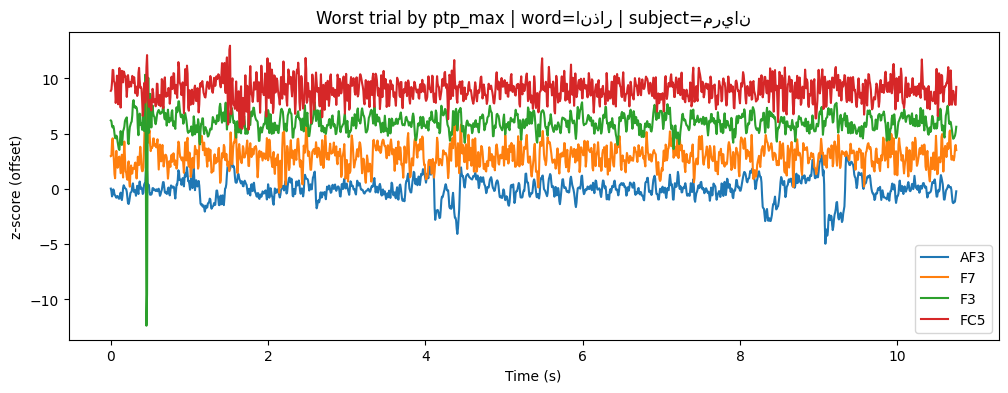

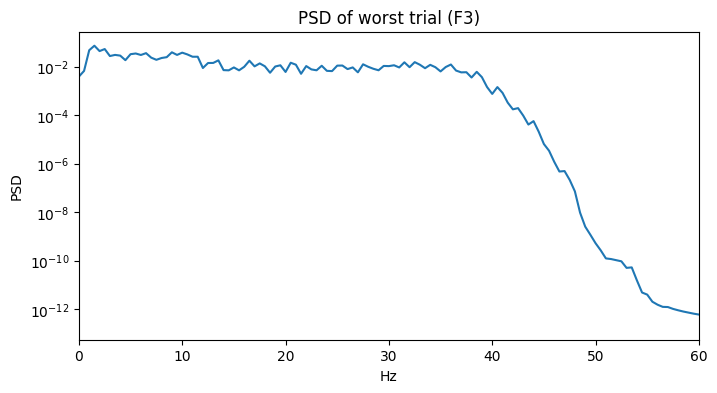

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import welch

worst_i = int(quality_df.sort_values("ptp_max", ascending=False).iloc[0]["i"])
trial = X[worst_i]
info = quality_df[quality_df["i"] == worst_i].iloc[0]

print("Worst trial index:", worst_i)
print(info)

t = np.arange(trial.shape[1]) / FS

plt.figure(figsize=(12,4))
for k, ch in enumerate(EEG_CHANNELS[:4]):
    plt.plot(t, trial[k] + k*3, label=ch)
plt.title(f"Worst trial by ptp_max | word={info['word']} | subject={info['subject']}")
plt.xlabel("Time (s)")
plt.ylabel("z-score (offset)")
plt.legend()
plt.show()

# PSD on F3
f, p = welch(trial[2], fs=FS, nperseg=256)
plt.figure(figsize=(8,4))
plt.semilogy(f, p)
plt.title("PSD of worst trial (F3)")
plt.xlabel("Hz")
plt.ylabel("PSD")
plt.xlim(0, 60)
plt.show()


#Subject-Wise Split

In [9]:
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
import numpy as np

# اختر واحد:
USE_LOSO = True   # True = LOSO, False = GroupKFold

if USE_LOSO:
    splitter = LeaveOneGroupOut()
    split_name = "LOSO"
else:
    splitter = GroupKFold(n_splits=5)
    split_name = "GroupKFold-5"

# تأكيد عدم وجود تداخل subjects
folds = list(splitter.split(np.arange(len(y)), y, groups=groups))
print(split_name, "| #folds:", len(folds))

for k, (tr, te) in enumerate(folds[:5], 1):  # اعرض أول 5 فقط
    overlap = set(groups[tr]).intersection(set(groups[te]))
    print(f"Fold {k}: train={len(tr)} test={len(te)} overlap_subjects={len(overlap)}")
    assert len(overlap) == 0


LOSO | #folds: 22
Fold 1: train=108 test=5 overlap_subjects=0
Fold 2: train=108 test=5 overlap_subjects=0
Fold 3: train=108 test=5 overlap_subjects=0
Fold 4: train=108 test=5 overlap_subjects=0
Fold 5: train=108 test=5 overlap_subjects=0


#Windowing function (1s)

In [10]:
import numpy as np

def make_windows(trial_14xT, win_len=128, stride=64):
    """
    trial_14xT: (14, T)
    Returns windows: (num_windows, 14, win_len)
    """
    ch, T = trial_14xT.shape
    if T < win_len:
        return np.empty((0, ch, win_len), dtype=trial_14xT.dtype)

    starts = range(0, T - win_len + 1, stride)
    windows = np.stack([trial_14xT[:, s:s+win_len] for s in starts], axis=0)
    return windows

# اختبار سريع على أول trial
w = make_windows(X[0], win_len=128, stride=64)
print("Example trial shape:", X[0].shape)
print("Windows shape:", w.shape)


Example trial shape: (14, 1454)
Windows shape: (21, 14, 128)


# Building windows inside a single Fold only (to be sure before we generalize)

In [11]:
WIN_LEN = 128   # 1 sec
STRIDE  = 64    # 0.5 sec

fold_id = 0  # أول fold للتجربة
train_idx, test_idx = folds[fold_id]

# subjects في هذا الفولد
train_subjects = set(groups[train_idx])
test_subjects  = set(groups[test_idx])
print("Train subjects:", len(train_subjects), "| Test subjects:", len(test_subjects))
print("Overlap:", len(train_subjects.intersection(test_subjects)))

# Build windows
Xtr_list, ytr_list = [], []
for i in train_idx:
    win = make_windows(X[i], win_len=WIN_LEN, stride=STRIDE)
    if len(win) == 0:
        continue
    Xtr_list.append(win)
    ytr_list.append(np.full((win.shape[0],), y[i], dtype=np.int64))

Xte_list, yte_list = [], []
for i in test_idx:
    win = make_windows(X[i], win_len=WIN_LEN, stride=STRIDE)
    if len(win) == 0:
        continue
    Xte_list.append(win)
    yte_list.append(np.full((win.shape[0],), y[i], dtype=np.int64))

Xtr_w = np.concatenate(Xtr_list, axis=0)
ytr_w = np.concatenate(ytr_list, axis=0)
Xte_w = np.concatenate(Xte_list, axis=0)
yte_w = np.concatenate(yte_list, axis=0)

print("Train windows:", Xtr_w.shape, "Train labels:", ytr_w.shape)
print("Test  windows:", Xte_w.shape, "Test labels:", yte_w.shape)

# توزيع الكلمات داخل هذا الفولد (windows)
unique, counts = np.unique(yte_w, return_counts=True)
print("Test windows per class:", dict(zip(unique.tolist(), counts.tolist())))


Train subjects: 21 | Test subjects: 1
Overlap: 0
Train windows: (2169, 14, 128) Train labels: (2169,)
Test  windows: (108, 14, 128) Test labels: (108,)
Test windows per class: {0: 23, 1: 21, 2: 21, 3: 22, 4: 21}


#Feature extraction functions

In [12]:
import numpy as np
from scipy.signal import welch
from scipy.stats import skew, kurtosis

def bandpower(x, fs, fmin, fmax):
    f, p = welch(x, fs=fs, nperseg=min(256, len(x)))
    m = (f >= fmin) & (f < fmax)
    if not np.any(m):
        return 0.0
    return float(np.trapz(p[m], f[m]))

def hjorth_params(x):
    # activity = var(x)
    dx = np.diff(x)
    ddx = np.diff(dx)
    var0 = np.var(x)
    var1 = np.var(dx) if len(dx) > 0 else 0.0
    var2 = np.var(ddx) if len(ddx) > 0 else 0.0

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-12))
    complexity = np.sqrt(var2 / (var1 + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def features_for_window(win_14xL, fs=128):
    """
    win_14xL: (14, L)
    returns 1D feature vector
    """
    bands = [(1,4),(4,8),(8,13),(13,30)]  # delta/theta/alpha/beta
    feats = []
    for ch in range(win_14xL.shape[0]):
        x = win_14xL[ch]

        # bandpower
        for lo, hi in bands:
            feats.append(bandpower(x, fs, lo, hi))

        # hjorth
        a, m, c = hjorth_params(x)
        feats.extend([a, m, c])

        # stats
        feats.extend([
            float(np.mean(x)),
            float(np.std(x)),
            float(skew(x)),
            float(kurtosis(x))
        ])

    return np.array(feats, dtype=np.float32)

def features_for_windows(Xw, fs=128):
    """
    Xw: (Nwin, 14, L)
    returns: (Nwin, F)
    """
    return np.stack([features_for_window(Xw[i], fs=fs) for i in range(Xw.shape[0])], axis=0)


Proposed Feature Set (per window, per channel – 14 channels)

For each 1-second EEG window, features are extracted independently from each of the 14 channels:

1. Bandpower features in four standard EEG frequency bands:

Delta (1–4 Hz)

Theta (4–8 Hz)

Alpha (8–13 Hz)

Beta (13–30 Hz)
→ 14 channels × 4 bands = 56 features

2. Hjorth parameters:

Activity

Mobility

Complexity
→ 14 channels × 3 parameters = 42 features

3. Time-domain statistical features:

Mean

Standard deviation

Skewness

Kurtosis
→ 14 channels × 4 statistics = 56 features

Total: 154 features per window

This feature dimensionality is well-suited for classical machine learning baselines (e.g., SVM, Logistic Regression, Random Forest) given the current dataset size.

##Extract features for the single fold we built (sanity check)

In [13]:
Ftr = features_for_windows(Xtr_w, fs=FS)
Fte = features_for_windows(Xte_w, fs=FS)

print("Ftr:", Ftr.shape, "Fte:", Fte.shape)
print("Num features:", Ftr.shape[1])


/tmp/ipykernel_4029/234632954.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(p[m], f[m]))


Ftr: (2169, 154) Fte: (108, 154)
Num features: 154


#Precompute windowed features for all trials and save them

In [14]:
# In this step, we generate sliding windows (1s length, 0.5s stride)
# for each preprocessed EEG trial and extract handcrafted features
# (bandpower, Hjorth parameters, statistical features) per window.
#
# The features are computed once for all trials (without any data split)
# and stored in an object array where each trial contains its own
# set of window-level feature vectors.
#
# This design ensures:
# - Clean and reusable pipeline
# - No data leakage (subject-wise splitting will be applied later)
# - Faster experimentation during model training
#
# The resulting feature arrays and metadata are saved to disk
# for reproducibility and future reuse.

import numpy as np
import os
import pandas as pd

# إعدادات windowing
WIN_LEN = 128   # 1 second
STRIDE  = 64    # 0.5 second

# تأكد أن TARGET_WORDS موجودة عندك
TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

# --- Precompute per-trial windows + features ---
F_trials = np.empty(len(X), dtype=object)   # each item: (nwin, 154)
W_trials = np.empty(len(X), dtype=object)   # each item: (nwin, 14, WIN_LEN) (اختياري)
nwin_list = np.zeros(len(X), dtype=np.int32)

for i in range(len(X)):
    wins = make_windows(X[i], win_len=WIN_LEN, stride=STRIDE)  # (nwin, 14, WIN_LEN)
    nwin_list[i] = wins.shape[0]

    # features per window
    feats = features_for_windows(wins, fs=FS)  # (nwin, 154)

    F_trials[i] = feats.astype(np.float32)

    # اختياري: خزّن الـ windows نفسها (لو ما تحتاجها للتدريب baseline، تقدر تعلّق السطرين)
    W_trials[i] = wins.astype(np.float32)

print("Trials:", len(X))
print("Total windows:", int(nwin_list.sum()))
print("Avg windows/trial:", float(nwin_list.mean()))
print("Feature shape example:", F_trials[0].shape)


/tmp/ipykernel_4029/234632954.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(p[m], f[m]))


Trials: 113
Total windows: 2277
Avg windows/trial: 20.150442477876105
Feature shape example: (21, 154)


In [ ]:
OUT_DIR = "/content/drive/MyDrive/EEG_Proj/features_5words_win1s_stride0p5s"
os.makedirs(OUT_DIR, exist_ok=True)

npz_path = os.path.join(OUT_DIR, "areeg_5words_window_features_per_trial.npz")
csv_path = os.path.join(OUT_DIR, "areeg_5words_trial_metadata.csv")

# احفظ features + labels + groups + nwin + إعدادات windowing
np.savez_compressed(
    npz_path,
    F_trials=F_trials,     # object array: each (nwin, 154)
    # إذا ما تحتاج windows الخام للتدريب baseline، تقدر تشيلها لتخفيف الحجم
    W_trials=W_trials,     # object array: each (nwin, 14, WIN_LEN)
    y=y,
    groups=groups,
    nwin=nwin_list,
    fs=FS,
    win_len=WIN_LEN,
    stride=STRIDE,
    words=np.array(TARGET_WORDS),
)

# metadata للرجوع للملفات/الأشخاص/الكلمات
meta_out.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:")
print(npz_path)
print(csv_path)


Saved:
/content/drive/MyDrive/EEG_Proj/features_5words_win1s_stride0p5s/areeg_5words_window_features_per_trial.npz
/content/drive/MyDrive/EEG_Proj/features_5words_win1s_stride0p5s/areeg_5words_trial_metadata.csv


In [15]:
import numpy as np
import pandas as pd

npz_path = "/content/drive/MyDrive/EEG_Proj/features_5words_win1s_stride0p5s/areeg_5words_window_features_per_trial.npz"
csv_path = "/content/drive/MyDrive/EEG_Proj/features_5words_win1s_stride0p5s/areeg_5words_trial_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
F_trials_loaded = data["F_trials"]
y_loaded = data["y"]
groups_loaded = data["groups"]
nwin_loaded = data["nwin"]

meta_loaded = pd.read_csv(csv_path)

print("Loaded trials:", len(F_trials_loaded))
print("Example F shape:", F_trials_loaded[0].shape)
print("Total windows:", int(nwin_loaded.sum()))
print("Unique subjects:", len(np.unique(groups_loaded)))
meta_loaded.head(3)


Loaded trials: 113
Example F shape: (21, 154)
Total windows: 2277
Unique subjects: 22


,path,word,y,subject_name,title_phrase,n_samples
0,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,2,aya,انذار,1454
1,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,2,شويكي,انذار,1384
2,/content/drive/MyDrive/EEG_Proj/كلمات/انذار/pa...,انذار,2,صنجي,انذار,1382


#Fold Preparation (LOSO) + Window→Trial mapping

In [16]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut

def build_fold_data_from_trial_features(F_trials, y, groups, fold_subject=None):
    """
    Prepare one LOSO fold using precomputed per-trial window features.

    Inputs:
      F_trials: object array length N_trials, each item shape (nwin_i, F)
      y: (N_trials,) class id per trial
      groups: (N_trials,) subject name per trial
      fold_subject: if provided, use this subject as test; otherwise take the first LOSO fold

    Returns:
      Xtr, ytr, tr_trial_ids
      Xte, yte, te_trial_ids
      test_subject
      train_trial_idx, test_trial_idx
    """
    logo = LeaveOneGroupOut()

    # pick fold
    chosen = None
    for tr_idx, te_idx in logo.split(np.arange(len(y)), y, groups=groups):
        subj = groups[te_idx][0]
        if (fold_subject is None) or (subj == fold_subject):
            chosen = (tr_idx, te_idx, subj)
            break

    if chosen is None:
        raise ValueError("Requested fold_subject not found in groups.")

    tr_idx, te_idx, test_subject = chosen

    # helper to flatten trial->windows with trial_id tracking
    def flatten(trial_indices, offset=0):
        X_list, y_list, tid_list = [], [], []
        for local_tid, i in enumerate(trial_indices):
            Fi = F_trials[i]  # (nwin, F)
            if Fi is None or len(Fi) == 0:
                continue
            X_list.append(Fi)
            y_list.append(np.full((Fi.shape[0],), y[i], dtype=np.int64))
            tid_list.append(np.full((Fi.shape[0],), local_tid + offset, dtype=np.int64))
        if len(X_list) == 0:
            return (np.empty((0, 0), dtype=np.float32),
                    np.empty((0,), dtype=np.int64),
                    np.empty((0,), dtype=np.int64))
        Xw = np.concatenate(X_list, axis=0).astype(np.float32)
        yw = np.concatenate(y_list, axis=0)
        tw = np.concatenate(tid_list, axis=0)
        return Xw, yw, tw

    # flatten train/test
    Xtr, ytr, tr_trial_ids = flatten(tr_idx, offset=0)
    Xte, yte, te_trial_ids = flatten(te_idx, offset=0)

    return (Xtr, ytr, tr_trial_ids,
            Xte, yte, te_trial_ids,
            test_subject, tr_idx, te_idx)

# ====== Try it on the first fold (or choose a subject name) ======
# fold_subject = None  # auto (first fold)
fold_subject = None

Xtr, ytr, tr_tid, Xte, yte, te_tid, test_subject, tr_idx, te_idx = build_fold_data_from_trial_features(
    F_trials_loaded, y_loaded, groups_loaded, fold_subject=fold_subject
)

print("Test subject:", test_subject)
print("Train trials:", len(tr_idx), "Test trials:", len(te_idx))
print("Train windows:", Xtr.shape, "Train labels:", ytr.shape, "Train trial_ids:", tr_tid.shape)
print("Test  windows:", Xte.shape, "Test labels:", yte.shape, "Test trial_ids:", te_tid.shape)

# sanity: ensure one subject in test and none of it in train
print("Unique train subjects:", len(set(groups_loaded[tr_idx])))
print("Unique test subjects :", len(set(groups_loaded[te_idx])))
print("Overlap subjects:", len(set(groups_loaded[tr_idx]).intersection(set(groups_loaded[te_idx]))))


Test subject: aya
Train trials: 108 Test trials: 5
Train windows: (2169, 154) Train labels: (2169,) Train trial_ids: (2169,)
Test  windows: (108, 154) Test labels: (108,) Test trial_ids: (108,)
Unique train subjects: 21
Unique test subjects : 1
Overlap subjects: 0


تستخدم F_trials (features لكل trial) و y و groups

تبني Train/Test على مستوى الـ trial

ثم تفردها إلى windows للـ model

وتُرجع أيضًا trial_id لكل window عشان نسوي majority vote لاحقًا

##Helper for Trial-level Voting

In [17]:
from collections import Counter
import numpy as np

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    """
    Convert window-level predictions into trial-level predictions by majority vote.
    Returns: trial_pred (n_trials_in_fold,)
    """
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)

    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        # majority vote
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]

    return trial_pred


#Baseline Model

In [ ]:
print(type(F_trials), len(F_trials))
print(type(y), len(y))
print(type(groups), len(groups))

<class 'numpy.ndarray'> 113
<class 'numpy.ndarray'> 113
<class 'numpy.ndarray'> 113


#Random Forest

In [18]:
import numpy as np

def subject_train_test_split(groups, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    subjects = np.unique(groups)
    rng.shuffle(subjects)

    n_test = max(1, int(round(len(subjects) * test_size)))
    test_subjects = set(subjects[:n_test])
    train_subjects = set(subjects[n_test:])

    train_idx = np.array([i for i, g in enumerate(groups) if g in train_subjects], dtype=int)
    test_idx  = np.array([i for i, g in enumerate(groups) if g in test_subjects], dtype=int)

    return train_idx, test_idx, train_subjects, test_subjects


def flatten_trial_features(F_trials, y, trial_indices):
    X_list, y_list, tid_list = [], [], []

    for local_tid, i in enumerate(trial_indices):
        Fi = F_trials[i]

        if Fi is None or len(Fi) == 0:
            continue

        X_list.append(Fi)
        y_list.append(np.full(Fi.shape[0], y[i], dtype=np.int64))
        tid_list.append(np.full(Fi.shape[0], local_tid, dtype=np.int64))

    Xw = np.concatenate(X_list, axis=0).astype(np.float32)
    yw = np.concatenate(y_list, axis=0)
    tw = np.concatenate(tid_list, axis=0)

    return Xw, yw, tw


# split subject-wise
train_idx, test_idx, train_subs, test_subs = subject_train_test_split(groups, test_size=0.2, seed=42)

print("Train subjects:", sorted(list(train_subs)))
print("Test subjects :", sorted(list(test_subs)))
print("Train trials:", len(train_idx))
print("Test trials :", len(test_idx))

# flatten trial-level features إلى window-level features
Xtr, ytr, tr_tid = flatten_trial_features(F_trials, y, train_idx)
Xte, yte, te_tid = flatten_trial_features(F_trials, y, test_idx)

print("Xtr shape:", Xtr.shape)
print("Xte shape:", Xte.shape)
print("ytr shape:", ytr.shape)
print("yte shape:", yte.shape)

Train subjects: [np.str_('aya'), np.str_('اسيد'), np.str_('الما'), np.str_('جمعة'), np.str_('حازم'), np.str_('حلاق'), np.str_('حمزة'), np.str_('رشيد'), np.str_('شاهين'), np.str_('شويكي'), np.str_('عمار'), np.str_('فارس'), np.str_('فاكهاني'), np.str_('ليال'), np.str_('محمد'), np.str_('ملاح'), np.str_('منى'), np.str_('نوار')]
Test subjects : [np.str_('صنجي'), np.str_('مريان'), np.str_('مضر'), np.str_('يمان')]
Train trials: 94
Test trials : 19
Xtr shape: (1899, 154)
Xte shape: (378, 154)
ytr shape: (1899,)
yte shape: (378,)


=== Random Forest | 5 Words | Window-level ===
Accuracy: 0.1958
Macro F1: 0.1735

=== Random Forest | 5 Words | Trial-level Majority Vote ===
Accuracy: 0.2105
Macro F1: 0.1794
Num test trials: 19


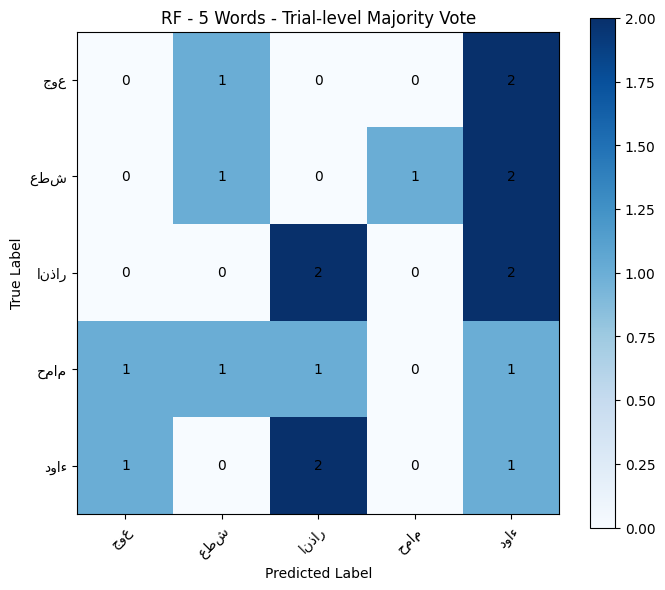


=== Random Forest | 5 Words | Trial-level Soft Vote ===
Accuracy: 0.2105
Macro F1: 0.1794


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

def plot_confusion_matrix_blue(cm, labels, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted Label",
        ylabel="True Label",
        title=title
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


rf_5 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# RF ما يحتاج scaling غالبًا
rf_5.fit(Xtr, ytr)

# Window-level
y_pred_w = rf_5.predict(Xte)
win_acc = accuracy_score(yte, y_pred_w)
win_f1  = f1_score(yte, y_pred_w, average="macro")

print("=== Random Forest | 5 Words | Window-level ===")
print("Accuracy:", round(win_acc, 4))
print("Macro F1:", round(win_f1, 4))

# Trial-level majority vote
y_true_trial = true_label_per_trial(yte, te_tid)
y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

trial_acc = accuracy_score(y_true_trial, y_pred_trial)
trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

print("\n=== Random Forest | 5 Words | Trial-level Majority Vote ===")
print("Accuracy:", round(trial_acc, 4))
print("Macro F1:", round(trial_f1, 4))
print("Num test trials:", len(y_true_trial))

cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(TARGET_WORDS))))
plot_confusion_matrix_blue(cm, TARGET_WORDS, "RF - 5 Words - Trial-level Majority Vote")

# Trial-level soft vote
proba = rf_5.predict_proba(Xte)

trial_ids = np.unique(te_tid)
y_pred_trial_soft = []
for tid in trial_ids:
    mean_proba = proba[te_tid == tid].mean(axis=0)
    y_pred_trial_soft.append(int(np.argmax(mean_proba)))
y_pred_trial_soft = np.array(y_pred_trial_soft)

trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

print("\n=== Random Forest | 5 Words | Trial-level Soft Vote ===")
print("Accuracy:", round(trial_acc_soft, 4))
print("Macro F1:", round(trial_f1_soft, 4))


=== Random Forest - 3-Class Grouping | Window-level ===
Accuracy: 0.4497
Macro F1: 0.3172

=== Random Forest - 3-Class Grouping | Trial-level Majority Vote ===
Accuracy: 0.4737
Macro F1: 0.3232


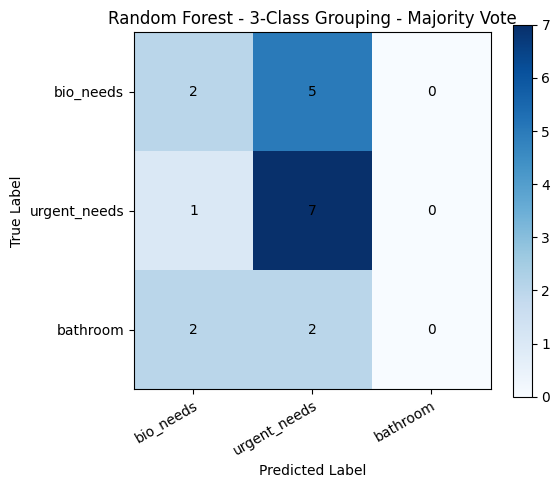


=== Random Forest - 3-Class Grouping | Trial-level Soft Vote ===
Accuracy: 0.4737
Macro F1: 0.3232

=== Random Forest - Binary Grouping | Window-level ===
Accuracy: 0.5635
Macro F1: 0.4638

=== Random Forest - Binary Grouping | Trial-level Majority Vote ===
Accuracy: 0.5263
Macro F1: 0.3448


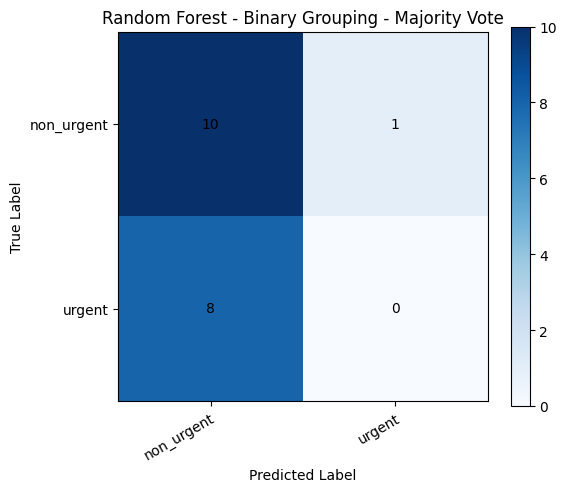


=== Random Forest - Binary Grouping | Trial-level Soft Vote ===
Accuracy: 0.5789
Macro F1: 0.3667


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

def plot_confusion_matrix_blue(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted Label",
        ylabel="True Label",
        title=title
    )
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


def run_rf_grouping(Xtr, ytr, tr_tid, Xte, yte, te_tid, class_map, class_names, title):
    ytr_g = np.array([class_map[int(v)] for v in ytr], dtype=np.int64)
    yte_g = np.array([class_map[int(v)] for v in yte], dtype=np.int64)

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(Xtr, ytr_g)

    # Window-level
    y_pred_w = rf.predict(Xte)
    win_acc = accuracy_score(yte_g, y_pred_w)
    win_f1  = f1_score(yte_g, y_pred_w, average="macro")

    print(f"\n=== {title} | Window-level ===")
    print("Accuracy:", round(win_acc, 4))
    print("Macro F1:", round(win_f1, 4))

    # Trial-level majority
    y_true_trial = true_label_per_trial(yte_g, te_tid)
    y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

    trial_acc = accuracy_score(y_true_trial, y_pred_trial)
    trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

    print(f"\n=== {title} | Trial-level Majority Vote ===")
    print("Accuracy:", round(trial_acc, 4))
    print("Macro F1:", round(trial_f1, 4))

    cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(class_names))))
    plot_confusion_matrix_blue(cm, class_names, f"{title} - Majority Vote")

    # Trial-level soft vote
    proba = rf.predict_proba(Xte)

    trial_ids = np.unique(te_tid)
    y_pred_trial_soft = []
    for tid in trial_ids:
        mean_proba = proba[te_tid == tid].mean(axis=0)
        y_pred_trial_soft.append(int(np.argmax(mean_proba)))
    y_pred_trial_soft = np.array(y_pred_trial_soft)

    trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
    trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

    print(f"\n=== {title} | Trial-level Soft Vote ===")
    print("Accuracy:", round(trial_acc_soft, 4))
    print("Macro F1:", round(trial_f1_soft, 4))

    return rf


# 3-class grouping
map_3class = {
    0: 0,  # جوع
    1: 0,  # عطش
    2: 1,  # انذار
    3: 2,  # حمام
    4: 1   # دواء
}
class_names_3 = ["bio_needs", "urgent_needs", "bathroom"]

rf_3class = run_rf_grouping(
    Xtr, ytr, tr_tid,
    Xte, yte, te_tid,
    class_map=map_3class,
    class_names=class_names_3,
    title="Random Forest - 3-Class Grouping"
)


# binary grouping
map_binary = {
    0: 0,  # جوع
    1: 0,  # عطش
    2: 1,  # انذار
    3: 0,  # حمام
    4: 1   # دواء
}
class_names_2 = ["non_urgent", "urgent"]

rf_binary = run_rf_grouping(
    Xtr, ytr, tr_tid,
    Xte, yte, te_tid,
    class_map=map_binary,
    class_names=class_names_2,
    title="Random Forest - Binary Grouping"
)

# Grouping Words

# Linear SVM


EXPERIMENT: 3-Class Grouping
Train subjects: [np.str_('aya'), np.str_('اسيد'), np.str_('الما'), np.str_('جمعة'), np.str_('حازم'), np.str_('حلاق'), np.str_('حمزة'), np.str_('رشيد'), np.str_('شاهين'), np.str_('شويكي'), np.str_('عمار'), np.str_('فارس'), np.str_('فاكهاني'), np.str_('ليال'), np.str_('محمد'), np.str_('ملاح'), np.str_('منى'), np.str_('نوار')]
Test subjects : [np.str_('صنجي'), np.str_('مريان'), np.str_('مضر'), np.str_('يمان')]
Train trials: 94
Test trials : 19
Xtr shape: (1899, 154)
Xte shape: (378, 154)
Train class counts: Counter({np.int64(1): 769, np.int64(0): 745, np.int64(2): 385})
Test class counts : Counter({np.int64(1): 161, np.int64(0): 141, np.int64(2): 76})

=== Window-level - Linear SVM ===
Accuracy: 0.4101
Macro F1: 0.2468

=== Trial-level (Majority Vote) ===
Accuracy: 0.4211
Macro F1: 0.2051
Num test trials: 19


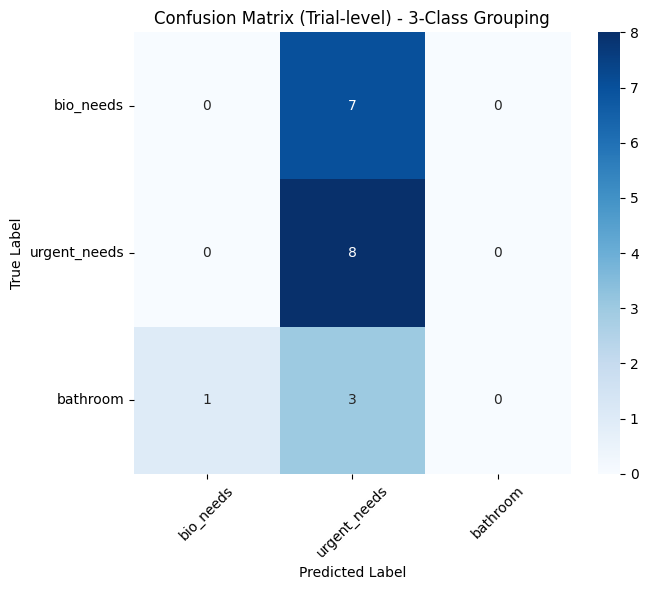


=== Trial-level (Soft Vote: mean probabilities) ===
Accuracy: 0.4211
Macro F1: 0.2051


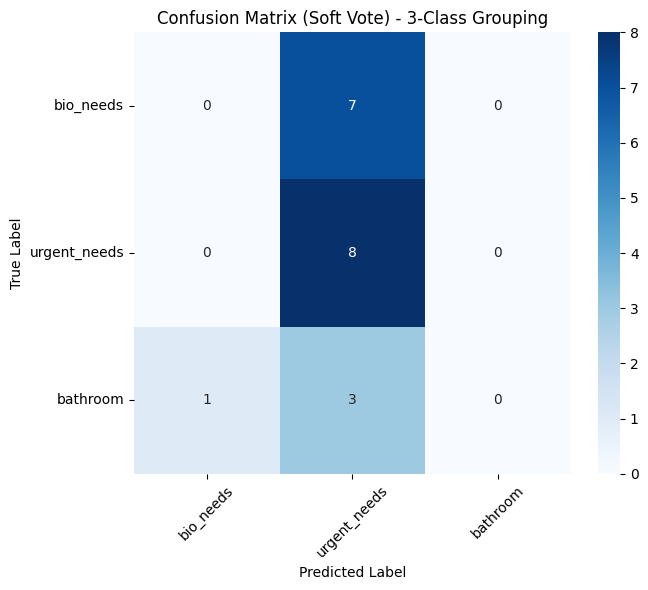


EXPERIMENT: Binary Grouping
Train subjects: [np.str_('aya'), np.str_('اسيد'), np.str_('الما'), np.str_('جمعة'), np.str_('حازم'), np.str_('حلاق'), np.str_('حمزة'), np.str_('رشيد'), np.str_('شاهين'), np.str_('شويكي'), np.str_('عمار'), np.str_('فارس'), np.str_('فاكهاني'), np.str_('ليال'), np.str_('محمد'), np.str_('ملاح'), np.str_('منى'), np.str_('نوار')]
Test subjects : [np.str_('صنجي'), np.str_('مريان'), np.str_('مضر'), np.str_('يمان')]
Train trials: 94
Test trials : 19
Xtr shape: (1899, 154)
Xte shape: (378, 154)
Train class counts: Counter({np.int64(0): 1130, np.int64(1): 769})
Test class counts : Counter({np.int64(0): 217, np.int64(1): 161})

=== Window-level - Linear SVM ===
Accuracy: 0.5741
Macro F1: 0.3647

=== Trial-level (Majority Vote) ===
Accuracy: 0.5789
Macro F1: 0.3667
Num test trials: 19


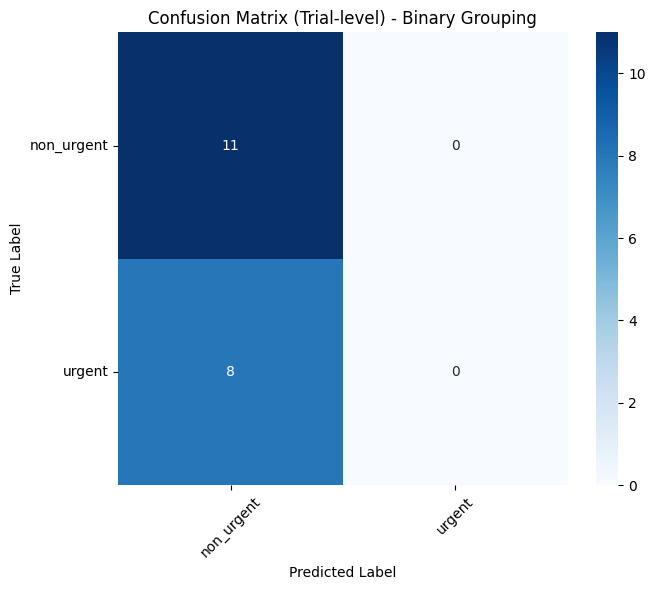


=== Trial-level (Soft Vote: mean probabilities) ===
Accuracy: 0.5789
Macro F1: 0.3667


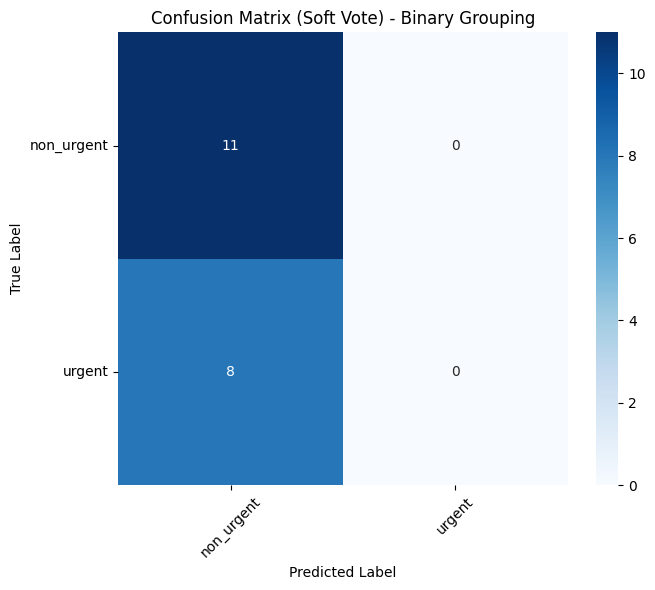


FINAL SUMMARY

3-Class Grouping Results:
window_acc: 0.4101
window_f1: 0.2468
trial_majority_acc: 0.4211
trial_majority_f1: 0.2051
trial_soft_acc: 0.4211
trial_soft_f1: 0.2051

Binary Grouping Results:
window_acc: 0.5741
window_f1: 0.3647
trial_majority_acc: 0.5789
trial_majority_f1: 0.3667
trial_soft_acc: 0.5789
trial_soft_f1: 0.3667


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from collections import Counter

# =========================================================
# تأكد أن هذه المتغيرات موجودة قبل تشغيل الخلية:
# F_trials, y, groups
# =========================================================

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def subject_train_test_split(groups, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    subjects = np.unique(groups)
    rng.shuffle(subjects)

    n_test = max(1, int(round(len(subjects) * test_size)))
    test_subjects = set(subjects[:n_test])
    train_subjects = set(subjects[n_test:])

    train_idx = np.array([i for i, g in enumerate(groups) if g in train_subjects], dtype=int)
    test_idx  = np.array([i for i, g in enumerate(groups) if g in test_subjects], dtype=int)

    return train_idx, test_idx, train_subjects, test_subjects

def flatten_trial_features(F_trials, y, trial_indices):
    X_list, y_list, tid_list = [], [], []

    for local_tid, i in enumerate(trial_indices):
        Fi = F_trials[i]

        if Fi is None:
            continue
        if len(Fi) == 0:
            continue

        X_list.append(Fi)
        y_list.append(np.full(Fi.shape[0], y[i], dtype=np.int64))
        tid_list.append(np.full(Fi.shape[0], local_tid, dtype=np.int64))

    Xw = np.concatenate(X_list, axis=0).astype(np.float32)
    yw = np.concatenate(y_list, axis=0)
    tw = np.concatenate(tid_list, axis=0)

    return Xw, yw, tw

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

def plot_cm(cm, class_names, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def run_grouped_experiment(F_trials, y, groups, class_map, class_names, title_suffix="", test_size=0.2, seed=42):
    # ===== Split بنفس الفكرة =====
    train_idx, test_idx, train_subs, test_subs = subject_train_test_split(groups, test_size=test_size, seed=seed)

    print("\n" + "="*70)
    print(f"EXPERIMENT: {title_suffix}")
    print("="*70)
    print("Train subjects:", sorted(list(train_subs)))
    print("Test subjects :", sorted(list(test_subs)))
    print("Train trials:", len(train_idx))
    print("Test trials :", len(test_idx))

    # ===== Flatten =====
    Xtr, ytr_original, tr_tid = flatten_trial_features(F_trials, y, train_idx)
    Xte, yte_original, te_tid = flatten_trial_features(F_trials, y, test_idx)

    print("Xtr shape:", Xtr.shape)
    print("Xte shape:", Xte.shape)

    # ===== Remap labels =====
    ytr = np.array([class_map[int(label)] for label in ytr_original], dtype=np.int64)
    yte = np.array([class_map[int(label)] for label in yte_original], dtype=np.int64)

    print("Train class counts:", Counter(ytr))
    print("Test class counts :", Counter(yte))

    # ===== Scaling =====
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    # ===== Same model exactly =====
    svm_base = LinearSVC(C=1.0, class_weight="balanced")
    clf = CalibratedClassifierCV(svm_base, method="sigmoid", cv=3)
    clf.fit(Xtr_s, ytr)

    # ===== Window-level =====
    y_pred_w = clf.predict(Xte_s)
    win_acc = accuracy_score(yte, y_pred_w)
    win_f1  = f1_score(yte, y_pred_w, average="macro")

    print("\n=== Window-level - Linear SVM ===")
    print("Accuracy:", round(win_acc, 4))
    print("Macro F1:", round(win_f1, 4))

    # ===== Trial-level Majority Vote =====
    y_true_trial = true_label_per_trial(yte, te_tid)
    y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

    trial_acc = accuracy_score(y_true_trial, y_pred_trial)
    trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

    print("\n=== Trial-level (Majority Vote) ===")
    print("Accuracy:", round(trial_acc, 4))
    print("Macro F1:", round(trial_f1, 4))
    print("Num test trials:", len(y_true_trial))

    cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(class_names))))
    plot_cm(cm, class_names, f"Confusion Matrix (Trial-level) - {title_suffix}")

    # ===== Trial-level Soft Vote =====
    proba = clf.predict_proba(Xte_s)

    trial_ids = np.unique(te_tid)
    y_pred_trial_soft = []
    for tid in trial_ids:
        mean_proba = proba[te_tid == tid].mean(axis=0)
        y_pred_trial_soft.append(int(np.argmax(mean_proba)))
    y_pred_trial_soft = np.array(y_pred_trial_soft)

    trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
    trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

    print("\n=== Trial-level (Soft Vote: mean probabilities) ===")
    print("Accuracy:", round(trial_acc_soft, 4))
    print("Macro F1:", round(trial_f1_soft, 4))

    cm_soft = confusion_matrix(y_true_trial, y_pred_trial_soft, labels=list(range(len(class_names))))
    plot_cm(cm_soft, class_names, f"Confusion Matrix (Soft Vote) - {title_suffix}")

    return {
        "window_acc": win_acc,
        "window_f1": win_f1,
        "trial_majority_acc": trial_acc,
        "trial_majority_f1": trial_f1,
        "trial_soft_acc": trial_acc_soft,
        "trial_soft_f1": trial_f1_soft
    }

# =========================================================
# 3-CLASS GROUPING
# جوع + عطش  -> bio_needs
# انذار + دواء -> urgent_needs
# حمام -> bathroom
# =========================================================
map_3class = {
    0: 0,  # جوع
    1: 0,  # عطش
    2: 1,  # انذار
    3: 2,  # حمام
    4: 1   # دواء
}
class_names_3 = ["bio_needs", "urgent_needs", "bathroom"]

results_3class = run_grouped_experiment(
    F_trials=F_trials,
    y=y,
    groups=groups,
    class_map=map_3class,
    class_names=class_names_3,
    title_suffix="3-Class Grouping",
    test_size=0.2,
    seed=42
)

# =========================================================
# BINARY GROUPING
# جوع + عطش + حمام -> non_urgent
# انذار + دواء -> urgent
# =========================================================
map_binary = {
    0: 0,  # جوع
    1: 0,  # عطش
    2: 1,  # انذار
    3: 0,  # حمام
    4: 1   # دواء
}
class_names_2 = ["non_urgent", "urgent"]

results_binary = run_grouped_experiment(
    F_trials=F_trials,
    y=y,
    groups=groups,
    class_map=map_binary,
    class_names=class_names_2,
    title_suffix="Binary Grouping",
    test_size=0.2,
    seed=42
)

# =========================================================
# Summary
# =========================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n3-Class Grouping Results:")
for k, v in results_3class.items():
    print(f"{k}: {v:.4f}")

print("\nBinary Grouping Results:")
for k, v in results_binary.items():
    print(f"{k}: {v:.4f}")

#RBF SVM


EXPERIMENT: RBF SVM - 3-Class Grouping

Label mapping:
جوع (0) -> bio_needs (0)
عطش (1) -> bio_needs (0)
انذار (2) -> urgent_needs (1)
حمام (3) -> bathroom (2)
دواء (4) -> urgent_needs (1)

Outer split:
Train subjects: [np.str_('aya'), np.str_('اسيد'), np.str_('الما'), np.str_('جمعة'), np.str_('حازم'), np.str_('حلاق'), np.str_('حمزة'), np.str_('رشيد'), np.str_('شاهين'), np.str_('شويكي'), np.str_('عمار'), np.str_('فارس'), np.str_('فاكهاني'), np.str_('ليال'), np.str_('محمد'), np.str_('ملاح'), np.str_('منى'), np.str_('نوار')]
Test subjects : [np.str_('صنجي'), np.str_('مريان'), np.str_('مضر'), np.str_('يمان')]
Train trials  : 94
Test trials   : 19

Window shapes:
Xtr: (1899, 154)
Xte: (378, 154)

Train class counts: Counter({np.int64(1): 769, np.int64(0): 745, np.int64(2): 385})
Test class counts : Counter({np.int64(1): 161, np.int64(0): 141, np.int64(2): 76})

Starting RBF tuning...
Fitting 4 folds for each of 42 candidates, totalling 168 fits

Best parameters found:
{'svc__C': 1, 'svc__

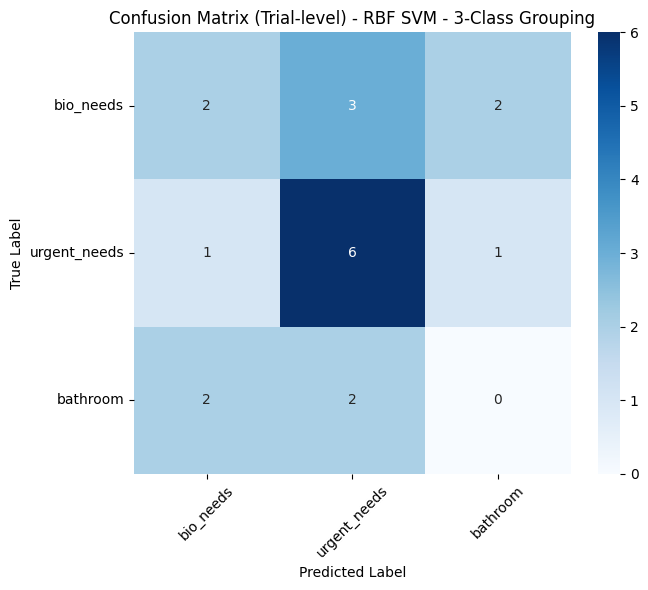


=== Trial-level (Soft Vote) ===
Accuracy         : 0.5263
Balanced Accuracy: 0.4286
Macro F1         : 0.3531


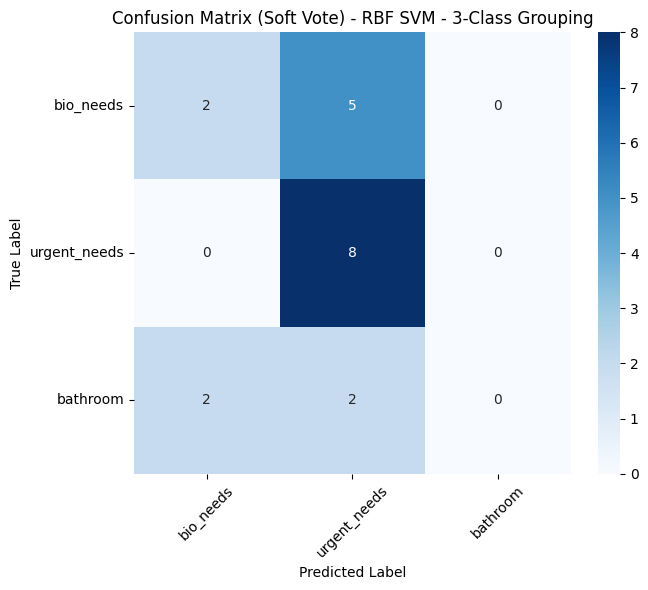


EXPERIMENT: RBF SVM - Binary Grouping

Label mapping:
جوع (0) -> non_urgent (0)
عطش (1) -> non_urgent (0)
انذار (2) -> urgent (1)
حمام (3) -> non_urgent (0)
دواء (4) -> urgent (1)

Outer split:
Train subjects: [np.str_('aya'), np.str_('اسيد'), np.str_('الما'), np.str_('جمعة'), np.str_('حازم'), np.str_('حلاق'), np.str_('حمزة'), np.str_('رشيد'), np.str_('شاهين'), np.str_('شويكي'), np.str_('عمار'), np.str_('فارس'), np.str_('فاكهاني'), np.str_('ليال'), np.str_('محمد'), np.str_('ملاح'), np.str_('منى'), np.str_('نوار')]
Test subjects : [np.str_('صنجي'), np.str_('مريان'), np.str_('مضر'), np.str_('يمان')]
Train trials  : 94
Test trials   : 19

Window shapes:
Xtr: (1899, 154)
Xte: (378, 154)

Train class counts: Counter({np.int64(0): 1130, np.int64(1): 769})
Test class counts : Counter({np.int64(0): 217, np.int64(1): 161})

Starting RBF tuning...
Fitting 4 folds for each of 42 candidates, totalling 168 fits

Best parameters found:
{'svc__C': 10, 'svc__gamma': 0.001}
Best CV balanced accuracy: 

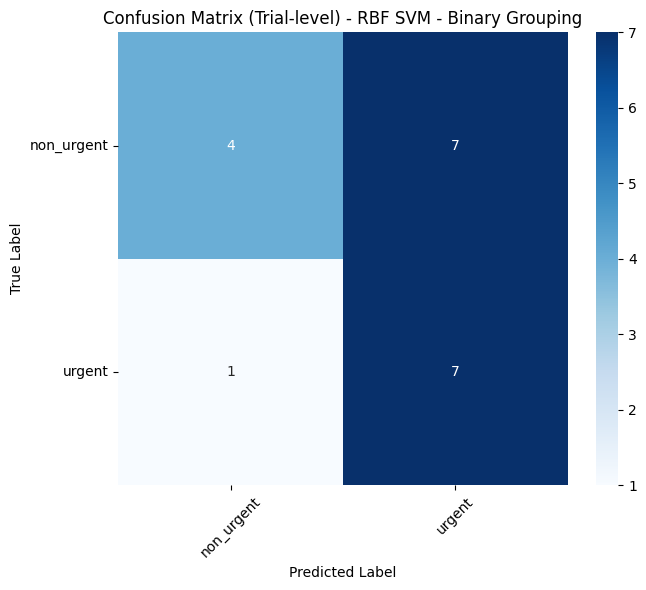


=== Trial-level (Soft Vote) ===
Accuracy         : 0.5789
Balanced Accuracy: 0.5852
Macro F1         : 0.5778


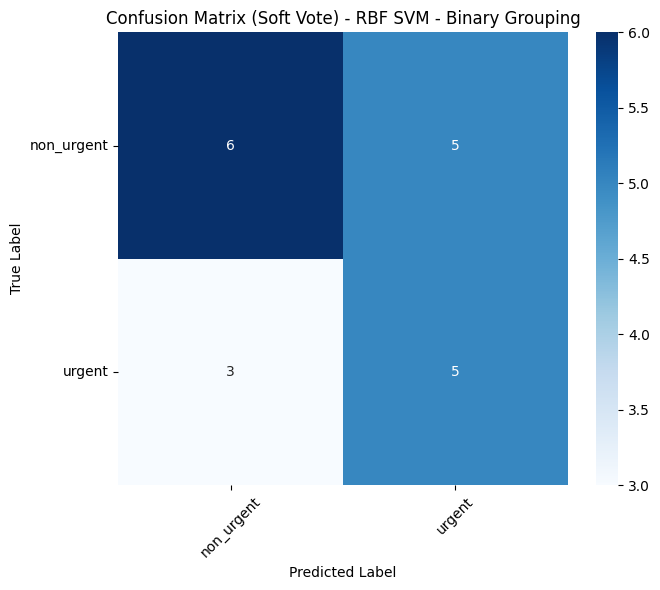


FINAL SUMMARY - RBF SVM

3-Class Grouping Results:
best_params: {'svc__C': 1, 'svc__gamma': 'scale'}
best_cv_balanced_acc: 0.3674
window_acc: 0.3968
window_bal_acc: 0.3506
window_f1: 0.3396
trial_majority_acc: 0.4211
trial_majority_bal_acc: 0.3452
trial_majority_f1: 0.3216
trial_soft_acc: 0.5263
trial_soft_bal_acc: 0.4286
trial_soft_f1: 0.3531

Binary Grouping Results:
best_params: {'svc__C': 10, 'svc__gamma': 0.001}
best_cv_balanced_acc: 0.5495
window_acc: 0.4947
window_bal_acc: 0.5150
window_f1: 0.4928
trial_majority_acc: 0.5789
trial_majority_bal_acc: 0.6193
trial_majority_f1: 0.5682
trial_soft_acc: 0.5789
trial_soft_bal_acc: 0.5852
trial_soft_f1: 0.5778


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    make_scorer
)

# =========================================================
# REQUIRED INPUTS ALREADY EXIST:
# F_trials, y, groups
# =========================================================

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def subject_train_test_split(groups, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    subjects = np.unique(groups)
    rng.shuffle(subjects)

    n_test = max(1, int(round(len(subjects) * test_size)))
    test_subjects = set(subjects[:n_test])
    train_subjects = set(subjects[n_test:])

    train_idx = np.array([i for i, g in enumerate(groups) if g in train_subjects], dtype=int)
    test_idx  = np.array([i for i, g in enumerate(groups) if g in test_subjects], dtype=int)

    return train_idx, test_idx, train_subjects, test_subjects

def flatten_trial_features_with_subjects(F_trials, y, groups, trial_indices):
    X_list, y_list, tid_list, subj_list = [], [], [], []

    for local_tid, i in enumerate(trial_indices):
        Fi = F_trials[i]

        if Fi is None:
            continue
        if len(Fi) == 0:
            continue

        X_list.append(Fi)
        y_list.append(np.full(Fi.shape[0], y[i], dtype=np.int64))
        tid_list.append(np.full(Fi.shape[0], local_tid, dtype=np.int64))
        subj_list.append(np.full(Fi.shape[0], groups[i]))

    Xw = np.concatenate(X_list, axis=0).astype(np.float32)
    yw = np.concatenate(y_list, axis=0)
    tw = np.concatenate(tid_list, axis=0)
    gw = np.concatenate(subj_list, axis=0)

    return Xw, yw, tw, gw

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)

    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        values, counts = np.unique(preds, return_counts=True)
        trial_pred[k] = values[np.argmax(counts)]

    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

def soft_vote_by_trial(proba_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    y_pred_trial_soft = []

    for tid in trial_ids:
        mean_proba = proba_windows[trial_ids_windows == tid].mean(axis=0)
        y_pred_trial_soft.append(int(np.argmax(mean_proba)))

    return np.array(y_pred_trial_soft, dtype=np.int64)

def plot_cm(cm, class_names, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def print_label_mapping(class_map, class_names):
    print("\nLabel mapping:")
    for i, w in enumerate(TARGET_WORDS):
        print(f"{w} ({i}) -> {class_names[class_map[i]]} ({class_map[i]})")

# ---------------------------------------------------------
# Main experiment
# ---------------------------------------------------------
def run_rbf_grouped_experiment(
    F_trials,
    y,
    groups,
    class_map,
    class_names,
    title_suffix="",
    test_size=0.2,
    seed=42
):
    print("\n" + "=" * 80)
    print(f"EXPERIMENT: {title_suffix}")
    print("=" * 80)

    print_label_mapping(class_map, class_names)

    # ===== Outer subject split =====
    train_idx, test_idx, train_subs, test_subs = subject_train_test_split(
        groups, test_size=test_size, seed=seed
    )

    print("\nOuter split:")
    print("Train subjects:", sorted(list(train_subs)))
    print("Test subjects :", sorted(list(test_subs)))
    print("Train trials  :", len(train_idx))
    print("Test trials   :", len(test_idx))

    # ===== Flatten =====
    Xtr, ytr_original, tr_tid, tr_groups = flatten_trial_features_with_subjects(
        F_trials, y, groups, train_idx
    )
    Xte, yte_original, te_tid, te_groups = flatten_trial_features_with_subjects(
        F_trials, y, groups, test_idx
    )

    print("\nWindow shapes:")
    print("Xtr:", Xtr.shape)
    print("Xte:", Xte.shape)

    # ===== Remap labels =====
    ytr = np.array([class_map[int(lbl)] for lbl in ytr_original], dtype=np.int64)
    yte = np.array([class_map[int(lbl)] for lbl in yte_original], dtype=np.int64)

    print("\nTrain class counts:", Counter(ytr))
    print("Test class counts :", Counter(yte))

    # ===== Pipeline =====
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"
        ))
    ])

    # ===== Parameter grid =====
    # Good practical search space for your dataset size
    param_grid = {
        "svc__C":     [0.1, 1, 5, 10, 20, 50],
        "svc__gamma": ["scale", 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
    }

    # ===== Group-aware inner CV =====
    n_train_subjects = len(np.unique(tr_groups))
    n_splits = min(4, n_train_subjects)
    if n_splits < 2:
        raise ValueError("Not enough train subjects for group-aware CV.")

    inner_cv = GroupKFold(n_splits=n_splits)

    scoring = {
        "balanced_acc": "balanced_accuracy",
        "macro_f1": make_scorer(f1_score, average="macro")
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit="balanced_acc",   # fairer than plain accuracy
        cv=inner_cv,
        n_jobs=-1,
        verbose=1
    )

    print("\nStarting RBF tuning...")
    grid.fit(Xtr, ytr, groups=tr_groups)

    best_model = grid.best_estimator_

    print("\nBest parameters found:")
    print(grid.best_params_)
    print("Best CV balanced accuracy:", round(grid.best_score_, 4))

    # optional: show top few
    cvres = grid.cv_results_
    order = np.argsort(cvres["rank_test_balanced_acc"])[:5]

    print("\nTop 5 parameter sets:")
    for rank_idx in order:
        params = cvres["params"][rank_idx]
        bal_acc = cvres["mean_test_balanced_acc"][rank_idx]
        macro_f1 = cvres["mean_test_macro_f1"][rank_idx]
        print(f"{params} | CV balanced_acc={bal_acc:.4f} | CV macro_f1={macro_f1:.4f}")

    # ===== Window-level evaluation =====
    y_pred_w = best_model.predict(Xte)
    proba_w = best_model.predict_proba(Xte)

    win_acc = accuracy_score(yte, y_pred_w)
    win_bal_acc = balanced_accuracy_score(yte, y_pred_w)
    win_f1 = f1_score(yte, y_pred_w, average="macro")

    print("\n=== Window-level (RBF SVM) ===")
    print("Accuracy         :", round(win_acc, 4))
    print("Balanced Accuracy:", round(win_bal_acc, 4))
    print("Macro F1         :", round(win_f1, 4))

    # ===== Trial-level majority vote =====
    y_true_trial = true_label_per_trial(yte, te_tid)
    y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

    trial_acc = accuracy_score(y_true_trial, y_pred_trial)
    trial_bal_acc = balanced_accuracy_score(y_true_trial, y_pred_trial)
    trial_f1 = f1_score(y_true_trial, y_pred_trial, average="macro")

    print("\n=== Trial-level (Majority Vote) ===")
    print("Accuracy         :", round(trial_acc, 4))
    print("Balanced Accuracy:", round(trial_bal_acc, 4))
    print("Macro F1         :", round(trial_f1, 4))
    print("Num test trials  :", len(y_true_trial))

    cm_trial = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(class_names))))
    plot_cm(cm_trial, class_names, f"Confusion Matrix (Trial-level) - {title_suffix}")

    # ===== Trial-level soft vote =====
    y_pred_trial_soft = soft_vote_by_trial(proba_w, te_tid)

    trial_soft_acc = accuracy_score(y_true_trial, y_pred_trial_soft)
    trial_soft_bal_acc = balanced_accuracy_score(y_true_trial, y_pred_trial_soft)
    trial_soft_f1 = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

    print("\n=== Trial-level (Soft Vote) ===")
    print("Accuracy         :", round(trial_soft_acc, 4))
    print("Balanced Accuracy:", round(trial_soft_bal_acc, 4))
    print("Macro F1         :", round(trial_soft_f1, 4))

    cm_soft = confusion_matrix(y_true_trial, y_pred_trial_soft, labels=list(range(len(class_names))))
    plot_cm(cm_soft, class_names, f"Confusion Matrix (Soft Vote) - {title_suffix}")

    return {
        "best_params": grid.best_params_,
        "best_cv_balanced_acc": grid.best_score_,
        "window_acc": win_acc,
        "window_bal_acc": win_bal_acc,
        "window_f1": win_f1,
        "trial_majority_acc": trial_acc,
        "trial_majority_bal_acc": trial_bal_acc,
        "trial_majority_f1": trial_f1,
        "trial_soft_acc": trial_soft_acc,
        "trial_soft_bal_acc": trial_soft_bal_acc,
        "trial_soft_f1": trial_soft_f1
    }

# =========================================================
# 3-CLASS GROUPING
# bio_needs    = جوع + عطش
# urgent_needs = انذار + دواء
# bathroom     = حمام
# =========================================================
map_3class = {
    0: 0,  # جوع -> bio_needs
    1: 0,  # عطش -> bio_needs
    2: 1,  # انذار -> urgent_needs
    3: 2,  # حمام -> bathroom
    4: 1   # دواء -> urgent_needs
}
class_names_3 = ["bio_needs", "urgent_needs", "bathroom"]

results_3class_rbf = run_rbf_grouped_experiment(
    F_trials=F_trials,
    y=y,
    groups=groups,
    class_map=map_3class,
    class_names=class_names_3,
    title_suffix="RBF SVM - 3-Class Grouping",
    test_size=0.2,
    seed=42
)

# =========================================================
# BINARY GROUPING
# non_urgent = جوع + عطش + حمام
# urgent     = انذار + دواء
# =========================================================
map_binary = {
    0: 0,  # جوع -> non_urgent
    1: 0,  # عطش -> non_urgent
    2: 1,  # انذار -> urgent
    3: 0,  # حمام -> non_urgent
    4: 1   # دواء -> urgent
}
class_names_2 = ["non_urgent", "urgent"]

results_binary_rbf = run_rbf_grouped_experiment(
    F_trials=F_trials,
    y=y,
    groups=groups,
    class_map=map_binary,
    class_names=class_names_2,
    title_suffix="RBF SVM - Binary Grouping",
    test_size=0.2,
    seed=42
)

# =========================================================
# FINAL SUMMARY
# =========================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY - RBF SVM")
print("=" * 80)

print("\n3-Class Grouping Results:")
for k, v in results_3class_rbf.items():
    if isinstance(v, dict):
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v:.4f}" if isinstance(v, (float, np.floating)) else f"{k}: {v}")

print("\nBinary Grouping Results:")
for k, v in results_binary_rbf.items():
    if isinstance(v, dict):
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v:.4f}" if isinstance(v, (float, np.floating)) else f"{k}: {v}")

##Train Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Window-level ===
Accuracy: 0.1667
Macro F1: 0.1268

=== Trial-level (Majority Vote) ===
Accuracy: 0.0
Macro F1: 0.0


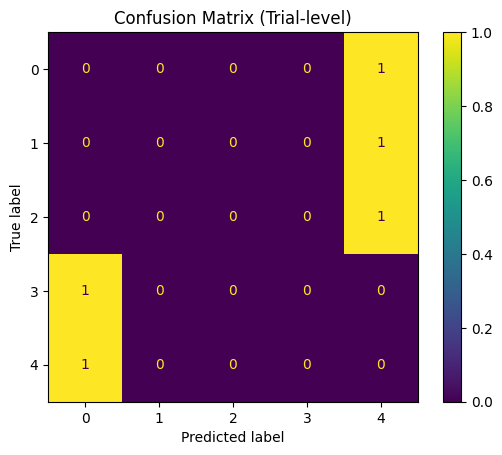

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ===== 1) Scale (FIT ONLY ON TRAIN) =====
scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr)
Xte_scaled = scaler.transform(Xte)

# ===== 2) Train Logistic Regression =====
clf = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)

clf.fit(Xtr_scaled, ytr)

# ===== 3) Window-level evaluation =====
y_pred_w = clf.predict(Xte_scaled)

win_acc = accuracy_score(yte, y_pred_w)
win_f1  = f1_score(yte, y_pred_w, average="macro")

print("=== Window-level ===")
print("Accuracy:", round(win_acc, 4))
print("Macro F1:", round(win_f1, 4))

# ===== 4) Trial-level evaluation (majority vote) =====
y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

# ground truth per trial
y_true_trial = []
for tid in sorted(np.unique(te_tid)):
    y_true_trial.append(yte[te_tid == tid][0])
y_true_trial = np.array(y_true_trial)

trial_acc = accuracy_score(y_true_trial, y_pred_trial)
trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

print("\n=== Trial-level (Majority Vote) ===")
print("Accuracy:", round(trial_acc, 4))
print("Macro F1:", round(trial_f1, 4))

# ===== 5) Confusion Matrix (Trial-level) =====
cm = confusion_matrix(y_true_trial, y_pred_trial)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix (Trial-level)")
plt.show()


In [ ]:
TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]
id2w = {i:w for i,w in enumerate(TARGET_WORDS)}

print("Trial-level results (this fold):")
for k, tid in enumerate(sorted(np.unique(te_tid))):
    true_id = int(yte[te_tid == tid][0])
    pred_id = int(y_pred_trial[k])
    print(f"trial {tid}: true={true_id}({id2w[true_id]})  pred={pred_id}({id2w[pred_id]})")


Trial-level results (this fold):
trial 0: true=2(انذار)  pred=4(دواء)
trial 1: true=0(جوع)  pred=4(دواء)
trial 2: true=3(حمام)  pred=0(جوع)
trial 3: true=4(دواء)  pred=0(جوع)
trial 4: true=1(عطش)  pred=4(دواء)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# majority class in TRAIN windows
maj = int(np.bincount(ytr).argmax())
y_pred_dummy_w = np.full_like(yte, maj)
win_acc_dummy = accuracy_score(yte, y_pred_dummy_w)

# trial-level dummy (same)
y_pred_dummy_trial = np.full(len(np.unique(te_tid)), maj)
y_true_trial = np.array([yte[te_tid==tid][0] for tid in sorted(np.unique(te_tid))])
trial_acc_dummy = accuracy_score(y_true_trial, y_pred_dummy_trial)

print("Dummy majority class:", maj, "(", TARGET_WORDS[maj], ")")
print("Dummy window-acc:", win_acc_dummy)
print("Dummy trial-acc :", trial_acc_dummy)


Dummy majority class: 4 ( دواء )
Dummy window-acc: 0.19444444444444445
Dummy trial-acc : 0.2


In [ ]:
import numpy as np

proba = clf.predict_proba(Xte_scaled)  # (n_windows, n_classes)

trial_ids = sorted(np.unique(te_tid))
y_pred_trial_soft = []
for tid in trial_ids:
    mean_proba = proba[te_tid == tid].mean(axis=0)
    y_pred_trial_soft.append(int(np.argmax(mean_proba)))
y_pred_trial_soft = np.array(y_pred_trial_soft)

from sklearn.metrics import accuracy_score, f1_score
trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

print("Trial-level (Soft vote) Accuracy:", trial_acc_soft)
print("Trial-level (Soft vote) Macro F1 :", trial_f1_soft)


Trial-level (Soft vote) Accuracy: 0.2
Trial-level (Soft vote) Macro F1 : 0.08


In [ ]:
import numpy as np
import pandas as pd

# استخدم fold اللي عندك (Xtr, ytr, Xte, yte)
# Xtr, ytr, Xte, yte are window-level features

feat_std = Xtr.std(axis=0)
near_zero = np.where(feat_std < 1e-6)[0]

print("Num features:", Xtr.shape[1])
print("Near-constant features in TRAIN:", len(near_zero))
print("Example indices:", near_zero[:20])

# عرض إحصائيات عامة
print(pd.Series(feat_std).describe())


Num features: 154
Near-constant features in TRAIN: 0
Example indices: []
count    154.000000
mean       0.363987
std        0.248281
min        0.073606
25%        0.127335
50%        0.305881
75%        0.575285
max        0.986108
dtype: float64


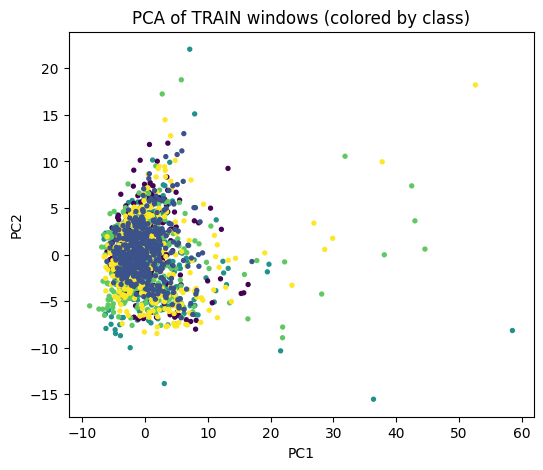

Explained variance ratio: [0.14506029 0.0756513 ] sum= 0.22071159


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xtr_s)

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=ytr, s=8)
plt.title("PCA of TRAIN windows (colored by class)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_, "sum=", pca.explained_variance_ratio_.sum())


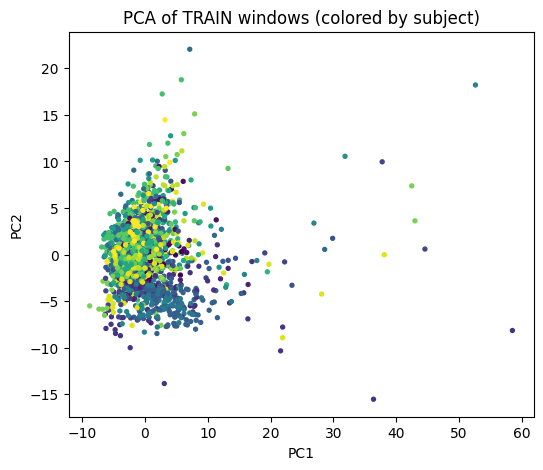

Unique subjects in this TRAIN fold: 21


In [ ]:
# نحتاج subject لكل window في train (tr_tid يعطينا trial_id داخل train fold)
# لكن tr_tid هنا هو trial_id محلي داخل الـ fold، فنربطه بـ subject عبر tr_idx

# خريطة: local trial_id -> global trial index
local_to_global = {local:i_global for local, i_global in enumerate(tr_idx)}
train_window_subject = np.array([groups_loaded[ local_to_global[int(tid)] ] for tid in tr_tid])

Z = pca.fit_transform(Xtr_s)

plt.figure(figsize=(6,5))
# نحول أسماء الأشخاص لأرقام للألوان
subj_ids = pd.factorize(train_window_subject)[0]
plt.scatter(Z[:,0], Z[:,1], c=subj_ids, s=8)
plt.title("PCA of TRAIN windows (colored by subject)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Unique subjects in this TRAIN fold:", len(np.unique(train_window_subject)))


#Subject-wise 80/20 split

In [ ]:
import numpy as np

def subject_train_test_split(groups, test_size=0.2, seed=42):
    """
    Split by unique subjects (groups). Returns train_trial_idx, test_trial_idx.
    """
    rng = np.random.default_rng(seed)
    subjects = np.unique(groups)
    rng.shuffle(subjects)

    n_test = max(1, int(round(len(subjects) * test_size)))
    test_subjects = set(subjects[:n_test])
    train_subjects = set(subjects[n_test:])

    test_idx = np.array([i for i, g in enumerate(groups) if g in test_subjects], dtype=int)
    train_idx = np.array([i for i, g in enumerate(groups) if g in train_subjects], dtype=int)

    return train_idx, test_idx, train_subjects, test_subjects

train_idx, test_idx, train_subs, test_subs = subject_train_test_split(groups_loaded, test_size=0.2, seed=42)

print("Unique subjects:", len(np.unique(groups_loaded)))
print("Train subjects:", len(train_subs), "Test subjects:", len(test_subs))
print("Train trials:", len(train_idx), "Test trials:", len(test_idx))
print("Overlap subjects:", len(set(groups_loaded[train_idx]).intersection(set(groups_loaded[test_idx]))))


Unique subjects: 22
Train subjects: 18 Test subjects: 4
Train trials: 94 Test trials: 19
Overlap subjects: 0


#Flatten per-trial window features into window-level train/test + trial_id mapping

In [ ]:
import numpy as np

def flatten_trial_features(F_trials, y, trial_indices):
    """
    Convert per-trial window features -> window-level arrays with trial_id mapping.
    Returns: Xw, yw, trial_ids_w (trial_id is local within this split)
    """
    X_list, y_list, tid_list = [], [], []

    for local_tid, i in enumerate(trial_indices):
        Fi = F_trials[i]  # (nwin, F)
        if Fi is None or len(Fi) == 0:
            continue

        X_list.append(Fi)
        y_list.append(np.full((Fi.shape[0],), y[i], dtype=np.int64))
        tid_list.append(np.full((Fi.shape[0],), local_tid, dtype=np.int64))

    Xw = np.concatenate(X_list, axis=0).astype(np.float32)
    yw = np.concatenate(y_list, axis=0)
    tw = np.concatenate(tid_list, axis=0)
    return Xw, yw, tw

Xtr, ytr, tr_tid = flatten_trial_features(F_trials_loaded, y_loaded, train_idx)
Xte, yte, te_tid = flatten_trial_features(F_trials_loaded, y_loaded, test_idx)

print("Train windows:", Xtr.shape, "Train labels:", ytr.shape)
print("Test  windows:", Xte.shape, "Test labels:", yte.shape)
print("Train trials (local):", len(np.unique(tr_tid)), "Test trials (local):", len(np.unique(te_tid)))


Train windows: (1899, 154) Train labels: (1899,)
Test  windows: (378, 154) Test labels: (378,)
Train trials (local): 94 Test trials (local): 19


In [ ]:
import pandas as pd
from collections import Counter

def trial_labels_from_indices(y, idx):
    return [int(y[i]) for i in idx]

print("Train trial class counts:", Counter(trial_labels_from_indices(y_loaded, train_idx)))
print("Test  trial class counts:", Counter(trial_labels_from_indices(y_loaded, test_idx)))


Train trial class counts: Counter({4: 20, 3: 19, 1: 19, 2: 18, 0: 18})
Test  trial class counts: Counter({2: 4, 3: 4, 4: 4, 1: 4, 0: 3})


#Train Logistic Regression (80/20 subject split) + Window & Trial metrics

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Window-level (80/20 subject split) ===
Accuracy: 0.209
Macro F1: 0.1992

=== Trial-level (Majority Vote) ===
Accuracy: 0.2632
Macro F1: 0.2415
Num test trials: 19


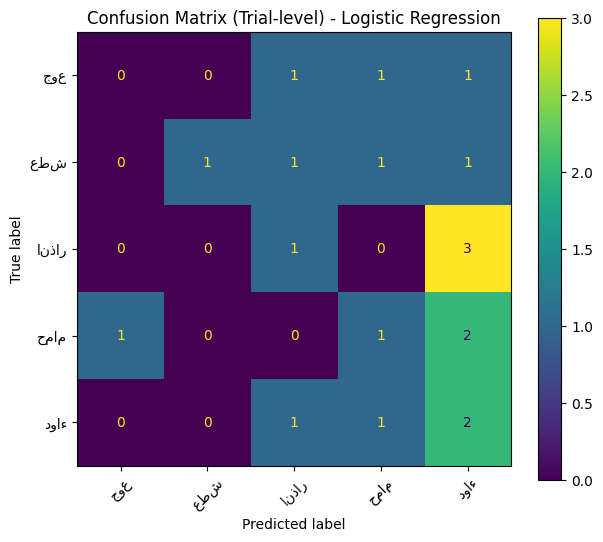


=== Trial-level (Soft Vote: mean probabilities) ===
Accuracy: 0.2105
Macro F1: 0.1567


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# كلماتك (للعرض)
TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    y_trial = np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)
    return y_trial

# ===== 1) Scaling (FIT ONLY ON TRAIN) =====
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

# ===== 2) Train Logistic Regression =====
clf = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)
clf.fit(Xtr_s, ytr)

# ===== 3) Window-level evaluation =====
y_pred_w = clf.predict(Xte_s)
win_acc = accuracy_score(yte, y_pred_w)
win_f1  = f1_score(yte, y_pred_w, average="macro")

print("=== Window-level (80/20 subject split) ===")
print("Accuracy:", round(win_acc, 4))
print("Macro F1:", round(win_f1, 4))

# ===== 4) Trial-level evaluation (Majority Vote) =====
y_true_trial = true_label_per_trial(yte, te_tid)
y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

trial_acc = accuracy_score(y_true_trial, y_pred_trial)
trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

print("\n=== Trial-level (Majority Vote) ===")
print("Accuracy:", round(trial_acc, 4))
print("Macro F1:", round(trial_f1, 4))
print("Num test trials:", len(y_true_trial))

# ===== 5) Trial-level Confusion Matrix =====
cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(TARGET_WORDS))))
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_WORDS)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, xticks_rotation=45, cmap=None)
plt.title("Confusion Matrix (Trial-level) - Logistic Regression")
plt.show()

# ===== 6) (Optional) Soft-vote trial prediction (often better) =====
proba = clf.predict_proba(Xte_s)  # (n_windows, n_classes)

trial_ids = np.unique(te_tid)
y_pred_trial_soft = []
for tid in trial_ids:
    mean_proba = proba[te_tid == tid].mean(axis=0)
    y_pred_trial_soft.append(int(np.argmax(mean_proba)))
y_pred_trial_soft = np.array(y_pred_trial_soft)

trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

print("\n=== Trial-level (Soft Vote: mean probabilities) ===")
print("Accuracy:", round(trial_acc_soft, 4))
print("Macro F1:", round(trial_f1_soft, 4))


#SVM

=== Window-level (80/20 subject split) - Linear SVM ===
Accuracy: 0.246
Macro F1: 0.1962

=== Trial-level (Majority Vote) ===
Accuracy: 0.3158
Macro F1: 0.2223
Num test trials: 19


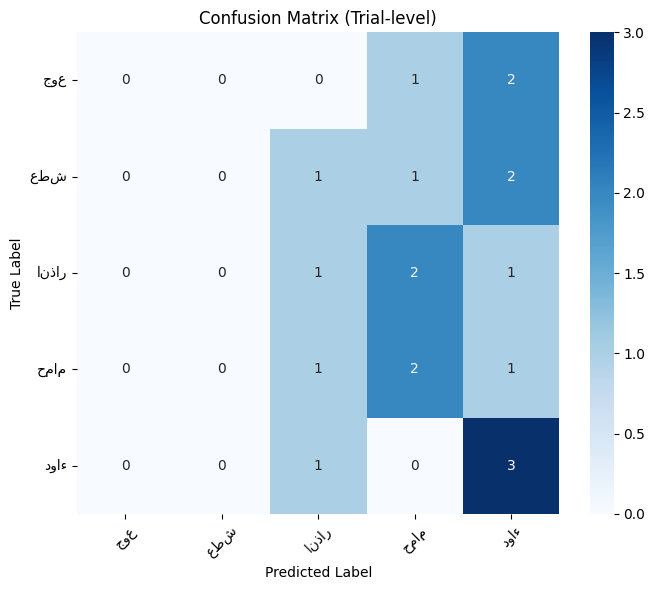


=== Trial-level (Soft Vote: mean probabilities) ===
Accuracy: 0.3684
Macro F1: 0.2778


In [45]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

# ===== 1) Scaling (FIT ONLY ON TRAIN) =====
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

# ===== 2) Train Linear SVM =====
# LinearSVC is fast & strong, but doesn't provide predict_proba by default.
svm_base = LinearSVC(C=1.0, class_weight=None)

# For fair comparison with LR soft-vote, we calibrate to get probabilities
# (calibration is fit on TRAIN only)
clf = CalibratedClassifierCV(svm_base, method="sigmoid", cv=3)
clf.fit(Xtr_s, ytr)

# ===== 3) Window-level evaluation =====
y_pred_w = clf.predict(Xte_s)

win_acc = accuracy_score(yte, y_pred_w)
win_f1  = f1_score(yte, y_pred_w, average="macro")

print("=== Window-level (80/20 subject split) - Linear SVM ===")
print("Accuracy:", round(win_acc, 4))
print("Macro F1:", round(win_f1, 4))

# ===== 4) Trial-level evaluation (Majority Vote) =====
y_true_trial = true_label_per_trial(yte, te_tid)
y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

trial_acc = accuracy_score(y_true_trial, y_pred_trial)
trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

print("\n=== Trial-level (Majority Vote) ===")
print("Accuracy:", round(trial_acc, 4))
print("Macro F1:", round(trial_f1, 4))
print("Num test trials:", len(y_true_trial))

# ===== 5) Confusion Matrix (Trial-level) =====
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(TARGET_WORDS))))

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=TARGET_WORDS,
    yticklabels=TARGET_WORDS,
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Trial-level)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ===== 6) Trial-level Soft Vote (mean calibrated probabilities) =====
proba = clf.predict_proba(Xte_s)  # (n_windows, n_classes)

trial_ids = np.unique(te_tid)
y_pred_trial_soft = []
for tid in trial_ids:
    mean_proba = proba[te_tid == tid].mean(axis=0)
    y_pred_trial_soft.append(int(np.argmax(mean_proba)))
y_pred_trial_soft = np.array(y_pred_trial_soft)

trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

print("\n=== Trial-level (Soft Vote: mean probabilities) ===")
print("Accuracy:", round(trial_acc_soft, 4))
print("Macro F1:", round(trial_f1_soft, 4))


#Save the model

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        LinearSVC(C=1.0, class_weight="balanced"),
        method="sigmoid",
        cv=3
    ))
])

final_model.fit(Xtr, ytr)
print("Final 5-word model trained successfully.")

Final 5-word model trained successfully.


In [47]:
import joblib
import json
import os
from datetime import datetime


save_dir = "/content/drive/MyDrive/Saved_Model"


os.makedirs(save_dir, exist_ok=True)

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

label_mapping = {
    "0": "جوع",
    "1": "عطش",
    "2": "انذار",
    "3": "حمام",
    "4": "دواء"
}

config = {
    "task_type": "5_word_classification",
    "model_type": "LinearSVM_Calibrated",
    "decision_type": "trial_level_soft_vote",
    "input_level": "window_features",
    "output_level": "trial_prediction",
    "n_classes": 5,
    "class_names": TARGET_WORDS,
    "feature_dim": int(Xtr.shape[1]),
    "soft_vote_method": "mean_probabilities_across_windows"
}

metadata = {
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "trial_soft_accuracy": 0.3684210526315789,
    "notes": "Best 5-word SVM model for integration"
}

# أسماء الملفات
model_path = os.path.join(save_dir, "natiqi_5word_svm_pipeline.pkl")
label_path = os.path.join(save_dir, "label_mapping.json")
config_path = os.path.join(save_dir, "config.json")
metadata_path = os.path.join(save_dir, "metadata.json")

# save
joblib.dump(final_model, model_path)

with open(label_path, "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("✅ Saved to Google Drive:")
print(model_path)
print(label_path)
print(config_path)
print(metadata_path)

✅ Saved to Google Drive:
/content/drive/MyDrive/Saved_Model/natiqi_5word_svm_pipeline.pkl
/content/drive/MyDrive/Saved_Model/label_mapping.json
/content/drive/MyDrive/Saved_Model/config.json
/content/drive/MyDrive/Saved_Model/metadata.json


In [48]:
import os

os.listdir("/content/drive/MyDrive/Saved_Model")

['natiqi_5word_svm_pipeline.pkl',
 'label_mapping.json',
 'config.json',
 'metadata.json']

In [49]:
import joblib
import os

model_path = "/content/drive/MyDrive/Saved_Model/natiqi_5word_svm_pipeline.pkl"

loaded_model = joblib.load(model_path)
print("Model loaded successfully.")
print(type(loaded_model))

Model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [50]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

In [51]:
# Window-level prediction
y_pred_w_loaded = loaded_model.predict(Xte)
proba_loaded = loaded_model.predict_proba(Xte)

# Window-level metrics
win_acc_loaded = accuracy_score(yte, y_pred_w_loaded)
win_f1_loaded  = f1_score(yte, y_pred_w_loaded, average="macro")

print("=== Loaded Model | Window-level ===")
print("Accuracy:", round(win_acc_loaded, 4))
print("Macro F1:", round(win_f1_loaded, 4))

# Trial-level majority
y_true_trial = true_label_per_trial(yte, te_tid)
y_pred_trial_majority = majority_vote_by_trial(y_pred_w_loaded, te_tid)

maj_acc_loaded = accuracy_score(y_true_trial, y_pred_trial_majority)
maj_f1_loaded  = f1_score(y_true_trial, y_pred_trial_majority, average="macro")

print("\n=== Loaded Model | Trial-level Majority Vote ===")
print("Accuracy:", round(maj_acc_loaded, 4))
print("Macro F1:", round(maj_f1_loaded, 4))

# Trial-level soft vote
trial_ids = np.unique(te_tid)
y_pred_trial_soft_loaded = []

for tid in trial_ids:
    mean_proba = proba_loaded[te_tid == tid].mean(axis=0)
    y_pred_trial_soft_loaded.append(int(np.argmax(mean_proba)))

y_pred_trial_soft_loaded = np.array(y_pred_trial_soft_loaded)

soft_acc_loaded = accuracy_score(y_true_trial, y_pred_trial_soft_loaded)
soft_f1_loaded  = f1_score(y_true_trial, y_pred_trial_soft_loaded, average="macro")

print("\n=== Loaded Model | Trial-level Soft Vote ===")
print("Accuracy:", round(soft_acc_loaded, 4))
print("Macro F1:", round(soft_f1_loaded, 4))

=== Loaded Model | Window-level ===
Accuracy: 0.2434
Macro F1: 0.1941

=== Loaded Model | Trial-level Majority Vote ===
Accuracy: 0.3158
Macro F1: 0.2223

=== Loaded Model | Trial-level Soft Vote ===
Accuracy: 0.3684
Macro F1: 0.2778


In [52]:
original_soft_acc = 0.3684210526315789

print("Original soft accuracy :", round(original_soft_acc, 6))
print("Loaded model accuracy  :", round(soft_acc_loaded, 6))

if abs(soft_acc_loaded - original_soft_acc) < 1e-9:
    print("✅ Perfect match: loaded model gives the same result.")
else:
    print("⚠️ Not an exact match. Check whether Xte / yte / te_tid are the same split used during saving.")

Original soft accuracy : 0.368421
Loaded model accuracy  : 0.368421
✅ Perfect match: loaded model gives the same result.


In [59]:
label_map = {
    0: "جوع",
    1: "عطش",
    2: "انذار",
    3: "حمام",
    4: "دواء"
}

trial_ids = np.unique(te_tid)
sample_tid = trial_ids[7]

X_one_trial = Xte[te_tid == sample_tid]
y_one_true = yte[te_tid == sample_tid][0]

proba_one = loaded_model.predict_proba(X_one_trial)
mean_proba_one = proba_one.mean(axis=0)

pred_class_one = int(np.argmax(mean_proba_one))
confidence_one = float(np.max(mean_proba_one))

print("True label index :", y_one_true)
print("True label word  :", label_map[int(y_one_true)])
print("Pred label index :", pred_class_one)
print("Pred label word  :", label_map[pred_class_one])
print("Confidence       :", round(confidence_one, 4))
print("Mean probabilities:", mean_proba_one)

True label index : 3
True label word  : حمام
Pred label index : 3
Pred label word  : حمام
Confidence       : 0.2182
Mean probabilities: [0.17850358 0.18994009 0.19781884 0.21824835 0.21548914]


#RBF SVM (80/20 subject split) + Majority & Soft vote

=== Window-level (80/20 subject split) - RBF SVM ===
Accuracy: 0.2354
Macro F1: 0.2239

=== Trial-level (Majority Vote) ===
Accuracy: 0.2105
Macro F1: 0.17
Num test trials: 19


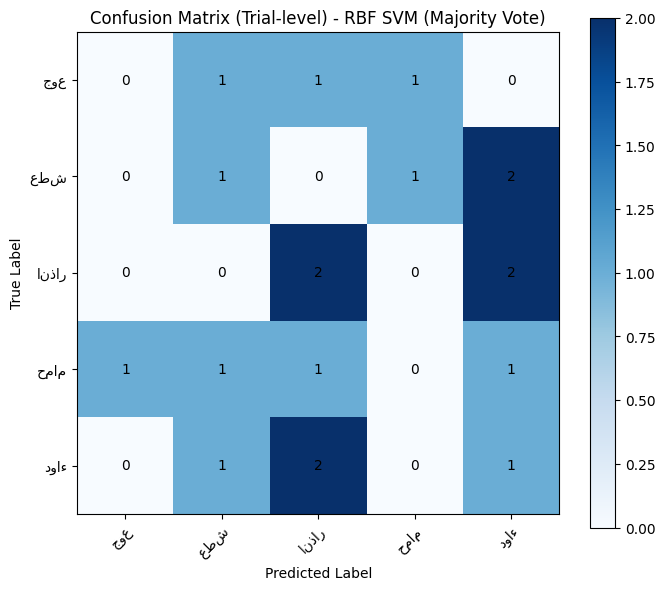


=== Trial-level (Soft Vote: mean probabilities) ===
Accuracy: 0.2105
Macro F1: 0.1824


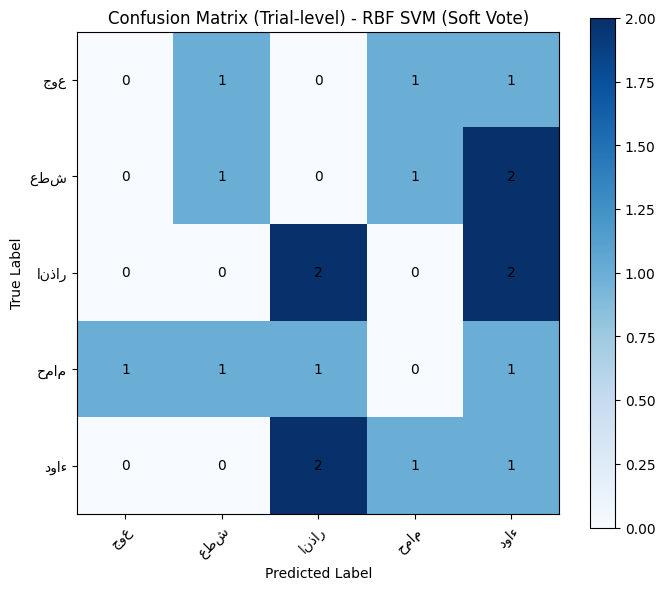

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from collections import Counter

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    trial_pred = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        trial_pred[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return trial_pred

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

def plot_confusion_matrix_blue(cm, labels, title):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted Label",
        ylabel="True Label",
        title=title
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

# ===== 1) Scaling (FIT ONLY ON TRAIN) =====
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

# ===== 2) Train RBF SVM =====
# probability=True enables predict_proba for soft voting (slower but fine here)
clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True
)
clf.fit(Xtr_s, ytr)

# ===== 3) Window-level evaluation =====
y_pred_w = clf.predict(Xte_s)

win_acc = accuracy_score(yte, y_pred_w)
win_f1  = f1_score(yte, y_pred_w, average="macro")

print("=== Window-level (80/20 subject split) - RBF SVM ===")
print("Accuracy:", round(win_acc, 4))
print("Macro F1:", round(win_f1, 4))

# ===== 4) Trial-level evaluation (Majority Vote) =====
y_true_trial = true_label_per_trial(yte, te_tid)
y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid)

trial_acc = accuracy_score(y_true_trial, y_pred_trial)
trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

print("\n=== Trial-level (Majority Vote) ===")
print("Accuracy:", round(trial_acc, 4))
print("Macro F1:", round(trial_f1, 4))
print("Num test trials:", len(y_true_trial))

cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(TARGET_WORDS))))
plot_confusion_matrix_blue(cm, TARGET_WORDS, "Confusion Matrix (Trial-level) - RBF SVM (Majority Vote)")

# ===== 5) Trial-level Soft Vote (mean probabilities) =====
proba = clf.predict_proba(Xte_s)  # (n_windows, n_classes)

trial_ids = np.unique(te_tid)
y_pred_trial_soft = []
for tid in trial_ids:
    mean_proba = proba[te_tid == tid].mean(axis=0)
    y_pred_trial_soft.append(int(np.argmax(mean_proba)))
y_pred_trial_soft = np.array(y_pred_trial_soft)

trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

print("\n=== Trial-level (Soft Vote: mean probabilities) ===")
print("Accuracy:", round(trial_acc_soft, 4))
print("Macro F1:", round(trial_f1_soft, 4))

cm_soft = confusion_matrix(y_true_trial, y_pred_trial_soft, labels=list(range(len(TARGET_WORDS))))
plot_confusion_matrix_blue(cm_soft, TARGET_WORDS, "Confusion Matrix (Trial-level) - RBF SVM (Soft Vote)")


#Precompute features (2s window, 1s stride) + Save

In [ ]:
import numpy as np
import os

# Windowing settings (2 seconds)
WIN_LEN = 256   # 2s at 128Hz
STRIDE  = 128   # 1s stride

def make_windows(trial_14xT, win_len=256, stride=128):
    ch, T = trial_14xT.shape
    if T < win_len:
        return np.empty((0, ch, win_len), dtype=trial_14xT.dtype)
    starts = range(0, T - win_len + 1, stride)
    return np.stack([trial_14xT[:, s:s+win_len] for s in starts], axis=0)

# يفترض إن عندك X (object array trials بعد preprocessing+zscore)
# و functions: features_for_windows موجودة من قبل

F_trials_2s = np.empty(len(X), dtype=object)
nwin_2s = np.zeros(len(X), dtype=np.int32)

for i in range(len(X)):
    wins = make_windows(X[i], win_len=WIN_LEN, stride=STRIDE)     # (nwin, 14, 256)
    nwin_2s[i] = wins.shape[0]
    feats = features_for_windows(wins, fs=FS)                     # (nwin, 154)
    F_trials_2s[i] = feats.astype(np.float32)

print("Trials:", len(X))
print("Total windows:", int(nwin_2s.sum()))
print("Avg windows/trial:", float(nwin_2s.mean()))
print("Example feature shape:", F_trials_2s[0].shape)

# Save for reuse
OUT_DIR = "/content/drive/MyDrive/EEG_Proj/features_5words_win2s_stride1s"
os.makedirs(OUT_DIR, exist_ok=True)

npz_path = os.path.join(OUT_DIR, "areeg_5words_window_features_per_trial_win2s.npz")
np.savez_compressed(
    npz_path,
    F_trials=F_trials_2s,
    y=y,
    groups=groups,
    nwin=nwin_2s,
    fs=FS,
    win_len=WIN_LEN,
    stride=STRIDE,
    words=np.array(["جوع","عطش","انذار","حمام","دواء"])
)

print("Saved:", npz_path)


/tmp/ipython-input-234632954.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(p[m], f[m]))


Trials: 113
Total windows: 1032
Avg windows/trial: 9.132743362831858
Example feature shape: (10, 154)
Saved: /content/drive/MyDrive/EEG_Proj/features_5words_win2s_stride1s/areeg_5words_window_features_per_trial_win2s.npz


#Subject-wise 80/20 split + flatten windows

In [ ]:
import numpy as np

def subject_train_test_split(groups, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    subjects = np.unique(groups)
    rng.shuffle(subjects)

    n_test = max(1, int(round(len(subjects) * test_size)))
    test_subjects = set(subjects[:n_test])
    train_subjects = set(subjects[n_test:])

    test_idx = np.array([i for i, g in enumerate(groups) if g in test_subjects], dtype=int)
    train_idx = np.array([i for i, g in enumerate(groups) if g in train_subjects], dtype=int)

    return train_idx, test_idx, train_subjects, test_subjects

def flatten_trial_features(F_trials, y, trial_indices):
    X_list, y_list, tid_list = [], [], []
    for local_tid, i in enumerate(trial_indices):
        Fi = F_trials[i]
        if Fi is None or len(Fi) == 0:
            continue
        X_list.append(Fi)
        y_list.append(np.full((Fi.shape[0],), y[i], dtype=np.int64))
        tid_list.append(np.full((Fi.shape[0],), local_tid, dtype=np.int64))
    Xw = np.concatenate(X_list, axis=0).astype(np.float32)
    yw = np.concatenate(y_list, axis=0)
    tw = np.concatenate(tid_list, axis=0)
    return Xw, yw, tw

train_idx, test_idx, train_subs, test_subs = subject_train_test_split(groups, test_size=0.2, seed=42)
print("Train subjects:", len(train_subs), "Test subjects:", len(test_subs))
print("Train trials:", len(train_idx), "Test trials:", len(test_idx))
print("Overlap subjects:", len(set(groups[train_idx]).intersection(set(groups[test_idx]))))

Xtr2, ytr2, tr_tid2 = flatten_trial_features(F_trials_2s, y, train_idx)
Xte2, yte2, te_tid2 = flatten_trial_features(F_trials_2s, y, test_idx)

print("Train windows:", Xtr2.shape, "Test windows:", Xte2.shape)
print("Test trials (local):", len(np.unique(te_tid2)))


Train subjects: 18 Test subjects: 4
Train trials: 94 Test trials: 19
Overlap subjects: 0
Train windows: (861, 154) Test windows: (171, 154)
Test trials (local): 19


#Train Linear SVM

=== Window-level (80/20 subject split) - Linear SVM (2s windows) ===
Accuracy: 0.2807
Macro F1: 0.2044

=== Trial-level (Majority Vote) ===
Accuracy: 0.3158
Macro F1: 0.2312
Num test trials: 19


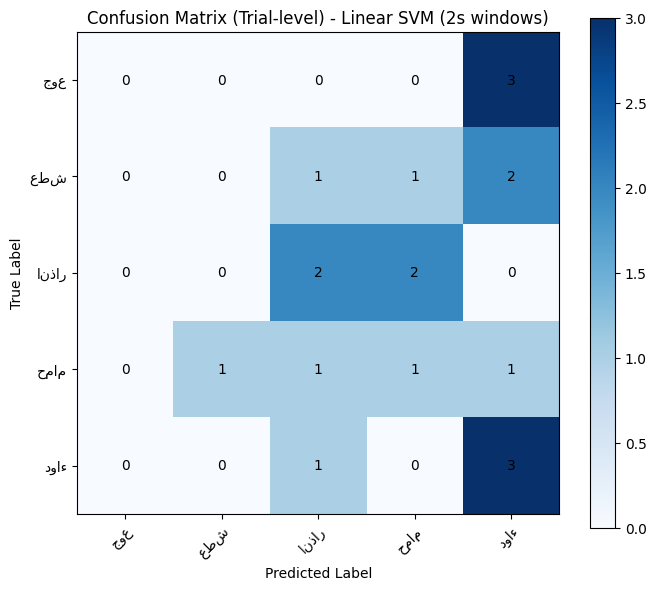


=== Trial-level (Soft Vote) ===
Accuracy: 0.3158
Macro F1: 0.2246


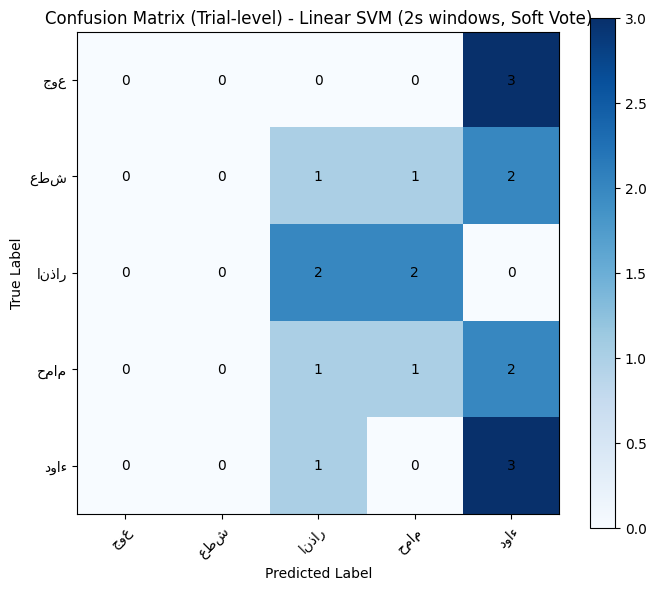

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from collections import Counter

TARGET_WORDS = ["جوع", "عطش", "انذار", "حمام", "دواء"]

def majority_vote_by_trial(y_pred_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    out = np.zeros(len(trial_ids), dtype=np.int64)
    for k, tid in enumerate(trial_ids):
        preds = y_pred_windows[trial_ids_windows == tid]
        out[k] = Counter(preds.tolist()).most_common(1)[0][0]
    return out

def true_label_per_trial(y_windows, trial_ids_windows):
    trial_ids = np.unique(trial_ids_windows)
    return np.array([y_windows[trial_ids_windows == tid][0] for tid in trial_ids], dtype=np.int64)

def plot_confusion_matrix_blue(cm, labels, title):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted Label",
        ylabel="True Label",
        title=title
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

# Scale (fit train only)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr2)
Xte_s = scaler.transform(Xte2)

# Linear SVM + calibration for probabilities (soft vote)
svm_base = LinearSVC(C=1.0)
clf = CalibratedClassifierCV(svm_base, method="sigmoid", cv=3)
clf.fit(Xtr_s, ytr2)

# Window-level
y_pred_w = clf.predict(Xte_s)
win_acc = accuracy_score(yte2, y_pred_w)
win_f1  = f1_score(yte2, y_pred_w, average="macro")

print("=== Window-level (80/20 subject split) - Linear SVM (2s windows) ===")
print("Accuracy:", round(win_acc, 4))
print("Macro F1:", round(win_f1, 4))

# Trial-level majority
y_true_trial = true_label_per_trial(yte2, te_tid2)
y_pred_trial = majority_vote_by_trial(y_pred_w, te_tid2)

trial_acc = accuracy_score(y_true_trial, y_pred_trial)
trial_f1  = f1_score(y_true_trial, y_pred_trial, average="macro")

print("\n=== Trial-level (Majority Vote) ===")
print("Accuracy:", round(trial_acc, 4))
print("Macro F1:", round(trial_f1, 4))
print("Num test trials:", len(y_true_trial))

cm = confusion_matrix(y_true_trial, y_pred_trial, labels=list(range(len(TARGET_WORDS))))
plot_confusion_matrix_blue(cm, TARGET_WORDS, "Confusion Matrix (Trial-level) - Linear SVM (2s windows)")

# Trial-level soft
proba = clf.predict_proba(Xte_s)
trial_ids = np.unique(te_tid2)
y_pred_trial_soft = []
for tid in trial_ids:
    mean_proba = proba[te_tid2 == tid].mean(axis=0)
    y_pred_trial_soft.append(int(np.argmax(mean_proba)))
y_pred_trial_soft = np.array(y_pred_trial_soft)

trial_acc_soft = accuracy_score(y_true_trial, y_pred_trial_soft)
trial_f1_soft  = f1_score(y_true_trial, y_pred_trial_soft, average="macro")

print("\n=== Trial-level (Soft Vote) ===")
print("Accuracy:", round(trial_acc_soft, 4))
print("Macro F1:", round(trial_f1_soft, 4))

cm2 = confusion_matrix(y_true_trial, y_pred_trial_soft, labels=list(range(len(TARGET_WORDS))))
plot_confusion_matrix_blue(cm2, TARGET_WORDS, "Confusion Matrix (Trial-level) - Linear SVM (2s windows, Soft Vote)")
